In [1]:
# !/usr/bin/env python

#------------------------------------------------------------------------------
###
#------------------------------------------------------------------------------
###
#------------------------------------------------------------------------------

# Declarations + Constants - v.2025

#######################################################
# Declares Libraries
#######################################################
### Standard Libaries ###
import string
import math
import sys
import os
### Additional Libraries ###
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.path as mplpath
import matplotlib.ticker
import pylab as py
import numpy as np
import scipy.stats as stats
import scipy.optimize as optimize
import scipy.integrate as integrate
import scipy.interpolate as interpolate
import astropy.wcs as wcs
import astropy.io as io
import aplpy
import inspect as inspect
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import figure
#######################################################
# Set Parameters
#######################################################
### Set Seed Variable ###
np.random.seed(146)
### Matplotlib Parameters ###
A = plt.rcParams.keys()
plt.rc('font', family = 'serif', size = 26)
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['axes.labelsize'] = 32
plt.rcParams['axes.linewidth'] = 4
plt.rcParams['lines.markersize'] = 8
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.labelsize'] = 42
plt.rcParams['ytick.labelsize'] = 42
plt.rcParams['xtick.major.size'] = 35
plt.rcParams['xtick.minor.size'] = 22
plt.rcParams['ytick.major.size'] = 35
plt.rcParams['ytick.minor.size'] = 22
plt.rcParams['xtick.major.width'] = 4
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 4
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['legend.numpoints'] = 1
### Bins ###
Bins_Hist_Mass = np.power(10, np.linspace(2, 9, num = 29))
Bins_Hist_Mass_Norm = np.power(10, np.linspace(-6, 2, num = 29))
Bins_Hist_Age = np.power(10, np.linspace(4, 11, num = 29))
### Analysis Parameters ###
os.environ['MKL_THREADING_LAYER'] = 'GNU'
mcmcnumsample = 2500
ncmcnumtune = 500
mcmcsigma = 2.
optimizesigma = 2.
bootstrapnumsample = 1000
plotstretchfactor = 1.00
masslimtestfactor = 3
num_interp = 50
### Calibration Sample Data ###
Ant_dist = 22.*1E6
LMC_dist = 0.05*1E6
M51_dist = 8.2*1E6
M83_dist = 4.5*1E6
NGC3256_dist = 36*1E6
NGC4214_dist = 3.1*1E6
NGC4449_dist = 3.8*1E6
SMC_dist = 0.06*1E6
###
Ant_SC_complimits = [np.power(10, 4.0), np.power(10, 4.25), np.power(10, 4.5)]
LMC_SC_complimits = [np.power(10, 2.5), np.power(10, 3.2), np.power(10, 3.25)]
M51_SC_complimits = [np.power(10, 3.5), np.power(10, 3.9), np.power(10, 4.0)]
M83_SC_complimits = [np.power(10, 3.3), np.power(10, 3.7), np.power(10, 4.0)]
NGC3256_SC_complimits = [np.power(10, 5.2), np.power(10, 5.2), np.power(10, 5.5)]
NGC4214_SC_complimits = [np.power(10, 2.5), np.power(10, 3.0), np.power(10, 3.0)]
NGC4449_SC_complimits = [np.power(10, 3.4), np.power(10, 4.0), np.power(10, 4.0)]
SMC_SC_complimits = [np.power(10, 2.5), np.power(10, 3.2), np.power(10, 3.25)]
###
Ant_SFR = 20.
LMC_SFR = 0.25
M51_SFR = 3.20
M83_SFR = 2.65
NGC3256_SFR = 50.
NGC4214_SFR = 0.11
NGC4449_SFR = 0.35
SMC_SFR = 0.06
###
Ant_SFRC1 = Ant_SFR * 1.00
LMC_SFRC1 = LMC_SFR * 0.70
M51_SFRC1 = M51_SFR * 0.90
M83_SFRC1 = M83_SFR * 0.60
NGC3256_SFRC1 = NGC3256_SFR * 1.00
NGC4214_SFRC1 = NGC4214_SFR * 1.00
NGC4449_SFRC1 = NGC4449_SFR * 0.85
SMC_SFRC1 = SMC_SFR * 0.90
### Folder Locations ###
DSS_folder = '/Users/Angus/Documents/SD/DSS/'
HST_folder = '/Users/Angus/Documents/SD/HST/'
#######################################################
# Check Folders
#######################################################
if not os.path.exists('./FiguresGMC/'):
	os.makedirs('./FiguresGMC')
if not os.path.exists('./FiguresSC/'):
	os.makedirs('./FiguresSC')
if not os.path.exists('./FiguresXB/'):
	os.makedirs('./FiguresXB')
if not os.path.exists('./FiguresSimSC/'):
	os.makedirs('./FiguresSimSC')
if not os.path.exists('./FiguresSummary/Radius/'):
	os.makedirs('./FiguresSummary/Radius')
if not os.path.exists('./FiguresSummary/'):
	os.makedirs('./FiguresSummary')
if not os.path.exists('./FiguresSCGMC/'):
	os.makedirs('./FiguresSCGMC')
if not os.path.exists('./FiguresSCCorr/'):
	os.makedirs('./FiguresSCCorr')
if not os.path.exists('./GridLike/'):
	os.makedirs('./GridLike')
if not os.path.exists('./Logs/'):
	os.makedirs('./Logs')
if not os.path.exists('./Output/'):
	os.makedirs('./Output')

#######################################################
# Main Functions
#######################################################

def rungalaxy_output(galname, galnameout, np_SC_C_array, SC_C_complimits, flag_massrange = 1, flag_addbin = 0, flag_makesubplots = 0):

	
	'''
	Explanation
	Input should be array of the form:
	Cluster Input: Galname[0], ID[1], RA[2], DEC[3], Mass[4], Mass_Error[5], Age[6], Age_Error[7]
	Complimits should be array with mass limits for each age bin
	flag_massrange = 1 = [3.0, 7.5]
	flag_massrange = 2 = [4.0, 8.5]
	'''

	### --==--==--==-- ###
	print('>>>')
	print('>>> {}_SC_00_AgeMass'.format(galnameout))
	print('>>>')
	fig, axes = plt.subplots(1, 1, sharex = 'all', sharey = 'all', figsize = (12, 12))
	fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
	if flag_addbin == 0:
		plotaxes_agemass(np_SC_C_array, '{}'.format(galname), SC_C_complimits, axes, 1, plotlegend = False)
	else:
		plotaxes_agemass(np_SC_C_array, '{}'.format(galname), SC_C_complimits, axes, 4, plotlegend = False)
	fig.text(0.5, 0.05, r'log (Age/yr)', ha = 'center', fontsize = 45)
	fig.text(0.04, 0.5, r'log (M/M$_\odot$)', va = 'center', rotation = 'vertical', fontsize = 45)
	plt.xscale('log', nonpositive = 'clip')
	plt.yscale('log', nonpositive = 'clip')
	axes.xaxis.set_major_formatter(log10_labels_format)
	axes.yaxis.set_major_formatter(log10_labels_format)
	axes.minorticks_off()
	plt.axis([np.power(10, 5.5), np.power(10, 9.5)] + [np.power(10, 2.5), np.power(10, 8.5)])
	plt.xticks([1E6, 1E7, 1E8, 1E9])
	plt.yticks([1E3, 1E4, 1E5, 1E6, 1E7, 1E8])
	plt.savefig('{}_SC_00_AgeMass.png'.format(galnameout))
	plt.close()

	if False:

		### --==--==--==-- ###
		print('>>>')
		print('>>> {}_SC_01_MSF'.format(galnameout))
		print('>>>')
		if flag_addbin == 0:
			fig, axes = plt.subplots(1, 3, sharex = 'all', sharey = 'all', figsize = (36, 12))
			fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
			plotaxes_mspecfit(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, 0, 0)
			plotaxes_mspecfit(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, 0, 0)
			plotaxes_mspecfit(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, 0, 0)
			fig.text(0.5, 0.05, r'log (M/M$_\odot$)', ha = 'center', fontsize = 45)
			fig.text(0.06, 0.5, r'log N (> M)', va = 'center', rotation = 'vertical', fontsize = 50)
		else:
			fig, axes = plt.subplots(1, 4, sharex = 'all', sharey = 'all', figsize = (48, 12))
			fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
			plotaxes_mspecfit(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, 0, 0)
			plotaxes_mspecfit(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, 0, 0)
			plotaxes_mspecfit(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, 0, 0)
			plotaxes_mspecfit(np_SC_C_array, '(400 Myr - 1 Gyr)', SC_C_complimits, axes[3], 4, 0, 0)
			fig.text(0.5, 0.05, r'log (M/M$_\odot$)', ha = 'center', fontsize = 45)
			fig.text(0.06, 0.5, r'log N (> M)', va = 'center', rotation = 'vertical', fontsize = 50)
		plt.xscale('log', nonpositive = 'clip')
		plt.yscale('log', nonpositive = 'clip')
		axes[0].xaxis.set_major_formatter(log10_labels_format)
		axes[0].yaxis.set_major_formatter(log10_labels_format)
		axes[0].minorticks_off()
		if flag_massrange == 2:
			plt.axis([1E4, np.power(10, 8.5)] + [np.power(10, -0.5), np.power(10, 3.5)])
			plt.xticks([1E4, 1E5, 1E6, 1E7, 1E8])
			plt.yticks([1E0, 1E1, 1E2, 1E3])
		else:
			plt.axis([1E3, np.power(10, 7.5)] + [np.power(10, -0.5), np.power(10, 3.5)])
			plt.xticks([1E3, 1E4, 1E5, 1E6, 1E7])
			plt.yticks([1E0, 1E1, 1E2, 1E3])
		plt.savefig('{}_SC_01_MSF.png'.format(galnameout))
		plt.close()

		if flag_makesubplots == True:


			for i in range(1, 4):

				if i == 1:
					out_string = '(< 10 Myr)'
				elif i == 2:
					out_string = '(10 - 100 Myr)'
				elif i == 3:
					out_string = '(100 - 400 Myr)'
				else:
					out_string = ''

				### --==--==--==-- ###
				print('>>>')
				print('>>> {}_SC_01_{}_MSF'.format(galnameout, i))
				print('>>>')
				fig, axes = plt.subplots(1, 1, sharex = 'all', sharey = 'all', figsize = (12, 12))
				fig.subplots_adjust(hspace = 0, wspace = 0)
				plotaxes_mspecfit(np_SC_C_array, '{} '.format(galname) + out_string, SC_C_complimits, axes, i, 0, 0)
				fig.text(0.5, 0.025, r'log (M/M$_\odot$)', ha = 'center', fontsize = 32)
				fig.text(0.05, 0.5, r'log N (> M)', va = 'center', rotation = 'vertical', fontsize = 32)
				plt.xscale('log', nonpositive = 'clip')
				plt.yscale('log', nonpositive = 'clip')
				axes.xaxis.set_major_formatter(log10_labels_format)
				axes.yaxis.set_major_formatter(log10_labels_format)
				axes.minorticks_off()
				if flag_massrange == 2:
					plt.axis([1E4, np.power(10, 8.5)] + [np.power(10, -0.5), np.power(10, 3.5)])
					plt.xticks([1E4, 1E5, 1E6, 1E7, 1E8])
					plt.yticks([1E0, 1E1, 1E2, 1E3])
				else:
					plt.axis([1E3, np.power(10, 7.5)] + [np.power(10, -0.5), np.power(10, 3.5)])
					plt.xticks([1E3, 1E4, 1E5, 1E6, 1E7])
					plt.yticks([1E0, 1E1, 1E2, 1E3])
				plt.savefig('{}_SC_01_{}_MSF.png'.format(galnameout, i))
				plt.close()

		### --==--==--==-- ###
		print('>>>')
		print('>>> {}_SC_02_Like'.format(galnameout))
		print('>>>')
		if flag_addbin == 0:
			fig, axes = plt.subplots(1, 3, sharex = 'all', sharey = 'all', figsize = (36, 12))
			fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
			if flag_massrange == 2:
				plotaxes_likelihood(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
				plotaxes_likelihood(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
				plotaxes_likelihood(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
			else:
				plotaxes_likelihood(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, 0, 0, 1, 'Test')
				plotaxes_likelihood(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, 0, 0, 1, 'Test')
				plotaxes_likelihood(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, 0, 0, 1, 'Test')
		else:
			fig, axes = plt.subplots(1, 4, sharex = 'all', sharey = 'all', figsize = (48, 12))
			fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
			if flag_massrange == 2:
				plotaxes_likelihood(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
				plotaxes_likelihood(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
				plotaxes_likelihood(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
			else:
				plotaxes_likelihood(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, 0, 0, 1, 'Test')
				plotaxes_likelihood(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, 0, 0, 1, 'Test')
				plotaxes_likelihood(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, 0, 0, 1, 'Test')
		fig.text(0.5, 0.05, r'log (M$_*$/M$_\odot$)', ha = 'center', fontsize = 45)
		fig.text(0.04, 0.5, r'$-\beta$', va = 'center', rotation = 'vertical', fontsize = 45)
		if flag_massrange == 2:
			plt.axis([4.0, 8.5] + [0, 3])
			plt.xticks([4.0, 5.0, 6.0, 7.0, 8.0])
			plt.yticks([0.0, 1.0, 2.0])
		else:
			plt.axis([3.0, 7.5] + [0, 3])
			plt.xticks([3.0, 4.0, 5.0, 6.0, 7.0])
			plt.yticks([0.0, 1.0, 2.0])
		plt.savefig('{}_SC_02_Like.png'.format(galnameout))
		plt.close()

		if flag_makesubplots == True:


			for i in range(1, 4):

				if i == 1:
					out_string = '(< 10 Myr)'
				elif i == 2:
					out_string = '(10 - 100 Myr)'
				elif i == 3:
					out_string = '(100 - 400 Myr)'
				else:
					out_string = ''

				### --==--==--==-- ###
				print('>>>')
				print('>>> {}_SC_02_{}_Like'.format(galnameout, i))
				print('>>>')
				fig, axes = plt.subplots(1, 1, sharex = 'all', sharey = 'all', figsize = (12, 12))
				fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
				if flag_massrange == 2:
					plotaxes_likelihood(np_SC_C_array, '{} '.format(galname) + out_string, SC_C_complimits, axes, i, [4.5, 2.75], 0, 1, 'Test', flag_massrange = 2)
				else:
					plotaxes_likelihood(np_SC_C_array, '{} '.format(galname) + out_string, SC_C_complimits, axes, i, 0, 0, 1, 'Test')
				fig.text(0.5, 0.05, r'log (M$_*$/M$_\odot$)', ha = 'center', fontsize = 45)
				fig.text(0.04, 0.5, r'$-\beta$', va = 'center', rotation = 'vertical', fontsize = 45)
				if flag_massrange == 2:
					plt.axis([4.0, 8.5] + [0, 3])
					plt.xticks([4.0, 5.0, 6.0, 7.0, 8.0])
					plt.yticks([0.0, 1.0, 2.0])
				else:
					plt.axis([3.0, 7.5] + [0, 3])
					plt.xticks([3.0, 4.0, 5.0, 6.0, 7.0])
					plt.yticks([0.0, 1.0, 2.0])
				plt.savefig('{}_SC_02_{}_Like.png'.format(galnameout, i))
				plt.close()

	### --==--==--==-- ###
	print('>>>')
	print('>>> {}_SC_03_Hist'.format(galnameout))
	print('>>>')
	fig, axes = plt.subplots(1, 3, sharex = 'all', sharey = 'all', figsize = (36, 12))
	fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
	plotaxes_histogram(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, 2)
	plotaxes_histogram(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, 2)
	plotaxes_histogram(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, 2)
	fig.text(0.5, 0.05, r'log (M/M$_\odot$)', ha = 'center', fontsize = 45)
	fig.text(0.04, 0.5, r'log (dN/dM)', va = 'center', rotation = 'vertical', fontsize = 45)
	plt.xscale('log', nonpositive = 'clip')
	plt.yscale('log', nonpositive = 'clip')
	axes[0].xaxis.set_major_formatter(log10_labels_format)
	axes[0].yaxis.set_major_formatter(log10_labels_format)
	axes[0].minorticks_off()
	if flag_massrange == 2:
		plt.axis([np.power(10, 4), np.power(10, 8.5)] + [1E-7, 1E-1])
		plt.xticks([1E4, 1E5, 1E6, 1E7, 1E8])
		plt.yticks([1E-6, 1E-4, 1E-2])
	else:
		plt.axis([np.power(10, 3), np.power(10, 7.5)] + [1E-7, 1E-1])
		plt.xticks([1E3, 1E4, 1E5, 1E6, 1E7])
		plt.yticks([1E-6, 1E-4, 1E-2])
	plt.savefig('{}_SC_03_Hist.png'.format(galnameout))
	plt.close()

	### --==--==--==-- ###
	print('>>>')
	print('>>> {}_SC_04_EqualHist'.format(galnameout))
	print('>>>')
	fig, axes = plt.subplots(1, 3, sharex = 'all', sharey = 'all', figsize = (36, 12))
	fig.subplots_adjust(hspace = 0, wspace = 0, bottom = 0.15)
	plotaxes_equalhistogram(np_SC_C_array, '{} (< 10 Myr)'.format(galname), SC_C_complimits, axes[0], 1, 2)
	plotaxes_equalhistogram(np_SC_C_array, '(10 - 100 Myr)', SC_C_complimits, axes[1], 2, 2)
	plotaxes_equalhistogram(np_SC_C_array, '(100 - 400 Myr)', SC_C_complimits, axes[2], 3, 2)
	fig.text(0.5, 0.05, r'log (M/M$_\odot$)', ha = 'center', fontsize = 45)
	fig.text(0.04, 0.5, r'log (dN/dM)', va = 'center', rotation = 'vertical', fontsize = 45)
	plt.xscale('log', nonpositive = 'clip')
	plt.yscale('log', nonpositive = 'clip')
	axes[0].xaxis.set_major_formatter(log10_labels_format)
	axes[0].yaxis.set_major_formatter(log10_labels_format)
	axes[0].minorticks_off()
	if flag_massrange == 2:
		plt.axis([np.power(10, 4), np.power(10, 8.5)] + [1E-7, 1E-1])
		plt.xticks([1E4, 1E5, 1E6, 1E7, 1E8])
		plt.yticks([1E-6, 1E-4, 1E-2])
	else:
		plt.axis([np.power(10, 3), np.power(10, 7.5)] + [1E-7, 1E-1])
		plt.xticks([1E3, 1E4, 1E5, 1E6, 1E7])
		plt.yticks([1E-6, 1E-4, 1E-2])
	plt.savefig('{}_SC_04_EqualHist.png'.format(galnameout))
	plt.close()

	return 0

#######################################################
# Sub-functions (plotaxes_agemass)
#######################################################

def plotaxes_agemass(gal_array, galname, complimits, plotaxes, flag, clustermarker = 'ro', plotlegend = True):
	
	'''
	Function: Make one age-mass plot at chosen location
	'''

	print('> Plotting {} - Age-Mass'.format(galname))

	plotaxes.plot(gal_array[:,6], gal_array[:,4], clustermarker, markersize = 4, alpha = 0.4)
	
	# Plot dash lines for standard 3 age bins
	if flag == 1:
		plotaxes.plot([np.power(10, 5.8), np.power(10, 7)], [complimits[0], complimits[0]], 'k--')
		plotaxes.plot([np.power(10, 7), np.power(10, 8)], [complimits[1], complimits[1]], 'k--')
		plotaxes.plot([np.power(10, 8), np.power(10, 8.6)], [complimits[2], complimits[2]], 'k--')
		plotaxes.plot([np.power(10, 7), np.power(10, 7)], [complimits[0], np.power(10, 8.5)], 'k--')
		plotaxes.plot([np.power(10, 8), np.power(10, 8)], [complimits[1], np.power(10, 8.5)], 'k--')
		plotaxes.plot([4 * np.power(10, 8), np.power(10, 8.6)], [complimits[2], np.power(10, 8.5)], 'k--')
	# Plot dash lines for 4 age bins
	elif flag == 4:
		# Horizontal Lines
		plotaxes.plot([np.power(10, 5.8), np.power(10, 7)], [complimits[0], complimits[0]], 'k--')
		plotaxes.plot([np.power(10, 7), np.power(10, 8)], [complimits[1], complimits[1]], 'k--')
		plotaxes.plot([np.power(10, 8), np.power(10, 8.6)], [complimits[2], complimits[2]], 'k--')
		plotaxes.plot([np.power(10, 8.6), np.power(10, 9.0)], [complimits[2], complimits[2]], 'k--')
		# Vertical Lines
		plotaxes.plot([np.power(10, 7), np.power(10, 7)], [complimits[0], np.power(10, 8.5)], 'k--')
		plotaxes.plot([np.power(10, 8), np.power(10, 8)], [complimits[1], np.power(10, 8.5)], 'k--')
		plotaxes.plot([np.power(10, 8.6), np.power(10, 8.6)], [complimits[2], np.power(10, 8.5)], 'k--')
		plotaxes.plot([np.power(10, 9.0), np.power(10, 9.0)], [complimits[3], np.power(10, 9.0)], 'k--')
	if plotlegend == True:
		plotaxes.annotate(galname, xy = (0.1, 0.80), xycoords='axes fraction', fontsize = 20)

	return 0

#######################################################
# Sub-functions (plotaxes_mspecfit)
#######################################################

def plotaxes_mspecfit(gal_array, galname, complimits, plotaxes, ageflag, errorflag, sigma, flag_mspecfitplot = 1):

	'''
	Function: Make one mspecfit plot at chosen location
	Sigma variable not currently used at this moment
	'''

	print('> Plotting {} - MSPECFIT with Error Flag {}'.format(galname, errorflag))

	gal_array_masslimit, age_label, gal_array_out = agecuts_outputarrays(gal_array, galname, complimits, ageflag)
	print('Mass Ranges in "{}" is [{:.1f}, {:.1f}]'.format(ageflag, np.log10(np.min(gal_array_masslimit[:,4])), np.log10(np.max(gal_array_masslimit[:,4]))))

	if ageflag in [1, '1r']:
		if len(gal_array_masslimit) > 0:
			mspecfitplot(gal_array_out[:,4], gal_array_masslimit[:,4], complimits[0], plotaxes, galname, '_A1', errorflag, flag_mspecfitplot = flag_mspecfitplot)
	elif ageflag in [2, '2r']:
		if len(gal_array_masslimit) > 0:
			mspecfitplot(gal_array_out[:,4], gal_array_masslimit[:,4], complimits[1], plotaxes, galname, '_A2', errorflag, flag_mspecfitplot = flag_mspecfitplot)
	elif ageflag in [3, '3r']:
		if len(gal_array_masslimit) > 0:
			mspecfitplot(gal_array_out[:,4], gal_array_masslimit[:,4], complimits[2], plotaxes, galname, '_A3', errorflag, flag_mspecfitplot = flag_mspecfitplot)
	elif ageflag in [4, '4r']:
		if len(gal_array_masslimit) > 0:
			mspecfitplot(gal_array_out[:,4], gal_array_masslimit[:,4], complimits[2], plotaxes, galname, '_A4', errorflag, flag_mspecfitplot = flag_mspecfitplot)
	else:
		if len(gal_array_masslimit) > 0:
			mspecfitplot(gal_array_out[:,4], gal_array_masslimit[:,4], np.nanmax(complimits), plotaxes, galname, '', errorflag, flag_mspecfitplot = flag_mspecfitplot)

def mspecfitplot(array1, array1_masslimit, complimits_val, plotaxes, galname, agename, errorflag, flag_mspecfitplot = 1):

	'''
	Function: Plot MSpecFit (subfunction for plotaxes_mmspecfit)
	'''

	ageout = ageflagconvert(agename)
	boxprops = dict(boxstyle = 'round', facecolor = 'white') # , alpha = 0.5

	# Sort data array, create x and y arrays
	sorted_data = np.sort(array1)
	xdata = np.concatenate([sorted_data[::-1]])
	ydata = np.arange(sorted_data.size) + 1
		
	# Filter array to those > complimit, output results
	filt_array = np.where(sorted_data >= complimits_val)
	data_lim = sorted_data[filt_array]
	sorted_data_lim = np.sort(data_lim)

	# Output results
	xdata_lim = np.concatenate([sorted_data_lim[::-1]])
	ydata_lim = np.arange(sorted_data_lim.size) + 1
	xdata_lim_float = xdata_lim.astype(float)
	ydata_lim_float = ydata_lim.astype(float)
	
	print('Running {}: Stated Completeness Limit = {}'.format(galname, np.log10(complimits_val)))
	print('Max/Min Mass - [{}, {}]'.format(np.round(np.log10(np.nanmin(xdata_lim_float)), 2), np.round(np.log10(np.nanmax(xdata_lim_float)), 2)))
	print('Num - [{}, {}]'.format(np.nanmax(ydata_lim_float), np.nanmin(ydata_lim_float)))
	
	if galname == 'All':
		plotaxes.step(xdata, ydata, 'k')
	elif galname == 'HXMB':
		plotaxes.step(xdata, ydata, 'b')
	elif galname == 'IMXB':
		plotaxes.step(xdata, ydata, 'g')
	elif galname == 'LMXB':
		plotaxes.step(xdata, ydata, 'r')
	else:
		plotaxes.step(xdata, ydata)

	plotaxes.plot([complimits_val, complimits_val], [1E-10, 1E10], 'k--')

	prevdir = os.getcwd()
	from idlpy import IDL
	num_iter = 100
	
	# Set outputs based on flags
	# 1: PL - Error + X Iter, TPL - Error + X Iter, Print Results
	# 0: PL - No Error + X Iter, TPL - No Error + X Iter
	# -1: PL - No Error + X Iter, TPL - DO NOT RUN
	if errorflag == 1:
		print('IDL - Error + {} iterations'.format(num_iter))
		fit_pl = IDL.mspecfit(np.array(array1_masslimit, dtype = np.float32), np.power(10, errorflag)*np.array(array1_masslimit, dtype = np.float32), notrunc = 'notrunc', bootiter = num_iter)
	elif errorflag == 0:
		print('IDL - No Error + {} iterations'.format(num_iter))
		fit_pl = IDL.mspecfit(np.array(array1_masslimit, dtype = np.float32), 1E-6*np.ones(len(array1_masslimit), dtype = np.float32), notrunc = 'notrunc', bootiter = num_iter)
	elif errorflag == -1:
		num_iter = 1
		print('IDL - No Error + {} iterations'.format(num_iter))
		fit_pl = IDL.mspecfit(np.array(array1_masslimit, dtype = np.float32), 1E-6*np.ones(len(array1_masslimit), dtype = np.float32), notrunc = 'notrunc', bootiter = num_iter)

	# Output
	fit_pl_out = [fit_pl[1], fit_pl[2] + 1]
	error_pl_out = [fit_pl[4], fit_pl[5]]
	print('PL:', fit_pl)
	print('Fit: N = {:.2f} +/- {:.2f}, Log(X) = {:.2f} +/- {:.2f}, Slope = {:.2f} +/- {:.2f}'.format(fit_pl[0], fit_pl[3], np.log10(fit_pl[1]), 0.434 * (fit_pl[4] / fit_pl[1]), fit_pl[2], fit_pl[5]))

	if flag_mspecfitplot != 3:
		# Set output based on flags
		if errorflag == 1:
			fit = IDL.mspecfit(np.array(array1_masslimit, dtype = np.float32), np.power(10, errorflag)*np.array(array1_masslimit, dtype = np.float32), bootiter = num_iter)
		elif errorflag == 0:
			fit = IDL.mspecfit(np.array(array1_masslimit, dtype = np.float32), 1E-6*np.ones(len(array1_masslimit), dtype = np.float32), bootiter = num_iter)
		elif errorflag == -1:
			fit_pl = IDL.mspecfit(np.array(array1_masslimit, dtype = np.float32), 1E-6*np.ones(len(array1_masslimit), dtype = np.float32), bootiter = num_iter)

		fit_out = [fit[0], fit[1], fit[2] + 1]
		error_out = [fit[3], fit[4], fit[5]]
		print('TPL:', fit)
		print('Fit: N = {:.2f} +/- {:.2f}, Log(X) = {:.2f} +/- {:.2f}, Slope = {:.2f} +/- {:.2f}'.format(fit[0], fit[3], np.log10(fit[1]), 0.434 * (fit[4] / fit[1]), fit[2], fit[5]))
	
	os.chdir(prevdir)

	mass_bins_log_plot = np.power(10, np.linspace(2, 8))
	if flag_mspecfitplot == 3:
		plotaxes.plot(mass_bins_log_plot, simplepowerlaw(mass_bins_log_plot, *fit_pl_out), 'k-.', label = r'{} - $-\beta$ = {:.2f} $\pm$ {:.2f}'.format(galname, -fit_pl[2], fit_pl[5]))
	elif flag_mspecfitplot == 2:
		plotaxes.plot(mass_bins_log_plot, simplepowerlaw(mass_bins_log_plot, *fit_pl_out), 'k-.', label = r'PL ($\beta$ = {:.2f} $\pm$ {:.2f})'.format(fit_pl[2], fit_pl[5]))
		plotaxes.plot(mass_bins_log_plot, truncatedpowerlaw(mass_bins_log_plot, *fit_out), 'k:', label = r'TPL (N$_c$ = {:.2f} $\pm$ {:.2f},'.format(fit[0], fit[3]) + '\n' + r'M$_c$ = {:.2f} $\pm$ {:.2f},'.format(np.log10(fit[1]), 0.434 * (fit[4] / fit[1])) + '\n' +  r'$\beta_c$ = {:.2f} $\pm$ {:.2f})'.format(fit[2], fit[5]))
		plotaxes.plot(fit[1], 1, 'r^', markersize = 30)
	elif errorflag > 0:
		plotaxes.plot(mass_bins_log_plot, simplepowerlaw(mass_bins_log_plot, *fit_pl_out), 'k-.', label = r'PL ($-\beta$ = {:.1f} $\pm$ {:.1f})'.format(-fit_pl[2], fit_pl[5]))
		plotaxes.plot(mass_bins_log_plot, truncatedpowerlaw(mass_bins_log_plot, *fit_out), 'k:', label = r'TPL (N$_c$ = {:.1f} $\pm$ {:.1f})'.format(fit[0], fit[3]))
	else:
		plotaxes.plot(mass_bins_log_plot, simplepowerlaw(mass_bins_log_plot, *fit_pl_out), 'k-.', label = r'PL ($-\beta$ = {:.1f} $\pm$ {:.1f})'.format(-fit_pl[2], fit_pl[5]))
		plotaxes.plot(mass_bins_log_plot, truncatedpowerlaw(mass_bins_log_plot, *fit_out), 'k:', label = r'TPL (N$_c$ = {:.1f} $\pm$ {:.1f})'.format(fit[0], fit[3]))
		
	if flag_mspecfitplot != 3:
		plotaxes.legend(loc = 'upper right', title = galname, framealpha = 1.0)
	else:
		plotaxes.legend(loc = 'upper right', framealpha = 1.0)

	return xdata_lim_float, ydata_lim_float

def plotgal_likelihood(gal_array, galname, complimits, plotrow, axes, flag):
	
	'''
	Function: Plot 3 likelihood Plot for 3 Age Bins in One Galaxy
	'''

	print('Starting {}'.format(galname))

	# Create classic 3 age bins
	print('Input Completeness Limits: {:.1e}, {:.1e}, {:.1e}'.format(complimits[0], complimits[1], complimits[2]))
	gal_array_age1_masslimit, age1_label, gal_array_age1_out = agecuts_outputarrays(gal_array, galname, complimits, 1)
	gal_array_age2_masslimit, age2_label, gal_array_age2_out = agecuts_outputarrays(gal_array, galname, complimits, 2)
	gal_array_age3_masslimit, age3_label, gal_array_age3_out = agecuts_outputarrays(gal_array, galname, complimits, 3)


	# array1, galname, agename, plotaxes, errorflag, sigma
	if flag == 1:

		if plotrow == -1:
			likelihoodplot_out_age1 = likelihoodplot(gal_array_age1_masslimit, galname, '_A1', axes[0], 1, 0.3, 0, 'Test')
			likelihoodplot_out_age2 = likelihoodplot(gal_array_age2_masslimit, galname, '_A2', axes[1], 1, 0.3, 0, 'Test')
			likelihoodplot_out_age3 = likelihoodplot(gal_array_age3_masslimit, galname, '_A3', axes[2], 1, 0.3, 0, 'Test')
		else:
			likelihoodplot_out_age1 = likelihoodplot(gal_array_age1_masslimit, galname, '_A1', axes[plotrow, 0], 1, 0.3, 0, 'Test')
			likelihoodplot_out_age2 = likelihoodplot(gal_array_age2_masslimit, galname, '_A2', axes[plotrow, 1], 1, 0.3, 0, 'Test')
			likelihoodplot_out_age3 = likelihoodplot(gal_array_age3_masslimit, galname, '_A3', axes[plotrow, 2], 1, 0.3, 0, 'Test')

	else:

		if plotrow == -1:
			likelihoodplot_out_age1 = likelihoodplot(gal_array_age1_masslimit, galname, '_A1', axes[0], 0, 0, 0, 'Test')
			likelihoodplot_out_age2 = likelihoodplot(gal_array_age2_masslimit, galname, '_A2', axes[1], 0, 0, 0, 'Test')
			likelihoodplot_out_age3 = likelihoodplot(gal_array_age3_masslimit, galname, '_A3', axes[2], 0, 0, 0, 'Test')
		else:
			likelihoodplot_out_age1 = likelihoodplot(gal_array_age1_masslimit, galname, '_A1', axes[plotrow, 0], 0, 0, 0, 'Test')
			likelihoodplot_out_age2 = likelihoodplot(gal_array_age2_masslimit, galname, '_A2', axes[plotrow, 1], 0, 0, 0, 'Test')
			likelihoodplot_out_age3 = likelihoodplot(gal_array_age3_masslimit, galname, '_A3', axes[plotrow, 2], 0, 0, 0, 'Test')

	return 0

#######################################################
# Sub-functions (plotaxes_likelihood)
#######################################################

def plotaxes_likelihood(gal_array, galname, complimits, plotaxes, ageflag, loc, sigma, output, outputfile, cutoff_mass_mult = 100, flag_simple = 0, age_flag = 1):

	'''
	Function: Make One Likelihood Plot at Chosen Location
	'''

	print('Starting {} - Likelihood (plotaxes)'.format(galname))

	if ageflag == 'GMC_P':
		print('>>> {}: 5% Threshold'.format(galname))
		complimits_val = np.nanmax(gal_array[:,4]) * 0.05
		gal_array_masslimit, age_label, gal_array_out = agecuts_outputarrays(gal_array, galname, complimits_val, ageflag)
	else:
		gal_array_masslimit, age_label, gal_array_out = agecuts_outputarrays(gal_array, galname, complimits, ageflag)

	if ageflag == 1:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, '_A1', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag == 2:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, '_A2', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag == 3:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, '_A3', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag == 5:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, '_A5', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag == 0:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, '_AL', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag == -1 or ageflag in ['XB_comb']:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, 'XB_comb', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag in ['C']:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, 'C', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	elif ageflag in ['GMC', 'GMC_P']:
		likelihoodplot(gal_array_masslimit, galname, 'GMC', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)
	else:
		if len(gal_array_masslimit) > 0:
			likelihoodplot(gal_array_masslimit, galname, '', plotaxes, loc, sigma, output, outputfile, cutoff_mass_mult, flag_simple = flag_simple, age_flag = age_flag)

def likelihoodplot(array, galname, agename, plotaxes, loc, sigma, output_flag, outputfile, cutoff_mass_mult = 100, flag_simple = 0, age_flag = 1):

	'''
	Function: Make One Likelihood Plot at Chosen Location
	'''

	# Select mass array
	array4 = array[:,4]

	# Test if the array contains data
	if len(array4) == 0:

		return 0

	# Reset variables
	res_loglikesimplepowerlaw = 0
	res_loglikeschechter = 0
	res_loglikeschechterwithslope2 = 0

	# Set age names
	ageout = ageflagconvert(agename)

	# Set error flag
	if abs(sigma) > 0:
		errorflag = 1
	else:
		errorflag = 0

	# Output to terminal
	print('>>> - <-> - <<<')
	print('Running Likelihood Routine on {} + {}:'.format(galname, ageout))
	print('>>> - <=> - <<<')

	# Set plot range and values
	if agename in ['GMC', 'GMC_P']:
		M0_low = 4.5
		M0_high = 9.0
		M_grid = np.power(10, np.linspace(M0_low, M0_high, 91))
		plot_likexticks = [5.0, 6.0, 7.0, 8.0]
		plot_likeyticks = [0.0, 1.0, 2.0, 3.0]
	elif agename in ['XB_comb']:
		M0_low = 3.0
		M0_high = 8.0
		M_grid = np.power(10, np.linspace(M0_low, M0_high, 101))
		plot_likexticks = [4.0, 5.0, 6.0, 7.0]
		plot_likeyticks = [0.0, 1.0, 2.0, 3.0]
	elif agename in ['XB', 'XB_P']:
		M0_low = 4.5
		M0_high = 8.5
		M_grid = np.power(10, np.linspace(M0_low, M0_high, 81))
		plot_likexticks = [5.0, 6.0, 7.0, 8.0]
		plot_likeyticks = [0.0, 1.0, 2.0, 3.0]
	elif agename in ['C', 'C_P']:
		M0_low = 1.0
		M0_high = 6.0	
		M_grid = np.power(10, np.linspace(M0_low, M0_high, 101))
		plot_likexticks = [2.0, 3.0, 4.0, 5.0]
		plot_likeyticks = [0.0, 1.0, 2.0, 3.0]
	elif age_flag == 2:
		M0_low = 4.0
		M0_high = 8.5
		M_grid = np.power(10, np.linspace(M0_low, M0_high, 91))
		plot_likexticks = [5.0, 6.0, 7.0, 8.0]
		plot_likeyticks = [0.0, 1.0, 2.0, 3.0]
	else:
		M0_low = 3.0
		M0_high = 7.5
		M_grid = np.power(10, np.linspace(M0_low, M0_high, 91))
		plot_likexticks = [4.0, 5.0, 6.0, 7.0]
		plot_likeyticks = [0.0, 1.0, 2.0, 3.0]

	# Define common variables	
	Beta_low = 0
	Beta_high = 3
	plot_likerange = [M0_low, M0_high] + [Beta_low, Beta_high]
	G_grid = np.linspace(Beta_low, Beta_high, 61)
	Value_grid = np.zeros((len(G_grid), len(M_grid)))
	boxprops = dict(boxstyle = 'round', facecolor = 'None')

	# Output important parameters and calculate the analytical estimator for the slope
	print('Num in array: {}'.format(len(array4)))
	print('Max/Min in array: {:.2f} - {:.2f}'.format(np.log10(np.nanmin(array4)), np.log10(np.nanmax(array4))))
	sumval = 0
	for i in range(0, len(array4)):
		sumval = sumval + np.log(array4[i]/np.nanmin(array4))
	alpha_est = 1 + len(array4) / sumval
	print('Beta Analytic - Estimator: {:.2f}'.format(alpha_est))

	# Set cutoff masses to be a multiple of the maximum mass in the catalogue
	max_mass = np.nanmax(array4)
	cutoff_mass = np.nanmax(array4) * cutoff_mass_mult
	print('Cutoff Mass Multiple Value: {}'.format(cutoff_mass_mult))
	print('Cutoff Mass (Integration Bound): {:.2f}'.format(np.log10(cutoff_mass)))

	# Define likelihood functions
	if errorflag == 0:

		print('Running - Original Version')

		# Define likelihood function for a Schechter function
		def loglikeschechter(params):

			M0 = params[0]
			Beta = params[1]

			LL = 0
			probsum = 0

			# Switch: Default Non-Log Transformed Method
			if True:
				normfun = lambda x: np.power((x / M0), -Beta) * np.exp(-(x / M0))
				norm = integrate.quad(normfun, np.nanmin(array4), cutoff_mass)[0]
				for i in range(0, len(array4)):
					numerator = np.power((array4[i] / M0), -Beta) * np.exp(-(array4[i] / M0))
					probsum = probsum + np.log(numerator / norm)

			# Switch: Log Transformed Method
			if False:
				logM0 = np.log10(M0)
				denominator = lambda x: np.power(np.power(10, (x - logM0)), -(Beta - 1)) * np.exp(-(np.power(10, x - logM0)))
				denominator_int = integrate.quad(denominator, np.log10(np.nanmin(array4)), np.log10(cutoff_mass))[0]
				for i in range(0, len(array4)):
					logM = np.log10(array4[i])
					numerator_int = np.power(np.power(10, (logM - logM0)), -(Beta - 1)) * np.exp(-(np.power(10, logM - logM0)))
					probsum = probsum + np.log(numerator_int / denominator_int)

			# Output Diagnostics
			# print('Test - Output no Error: {:.2e}, {:.2f}, L:{:.2f}'.format(M0, Beta, -probsum))

			LL = LL + probsum

			return -(LL)

		def loglikesimplepowerlaw(params):

			Beta = params

			LL = 0
			probsum = 0
			M0 = np.nanmin(array4)
			normfun = lambda x: np.power((x / M0), -Beta)
			norm = integrate.quad(normfun, np.nanmin(array4), cutoff_mass)[0]
			for i in range(0, len(array4)):
				probsum = probsum + np.log(np.power((array4[i] / M0), -Beta) / norm)		
			LL = LL + probsum

			return -(LL)

		def loglikeschechterwithslope2(params):

			M0 = params

			LL = 0
			probsum = 0
			normfun = lambda x: np.power((x / M0), -2) * np.exp(-(x / M0))
			norm = integrate.quad(normfun, np.nanmin(array4), cutoff_mass)[0]
			for i in range(0, len(array4)):
				probsum = probsum + np.log(np.power((array4[i] / M0), -2) * np.exp(-(array4[i] / M0)) / norm)
			LL = LL + probsum

			return -(LL)

	else:

		print('Running - With Errors')

		def loglikeschechter(params):

			M0 = params[0]
			Beta = params[1]

			LL = 0
			probsum = 0

			# Switch: Log-Normal Distribution ^^
			if True:

				# Define mass/mass-diff/function arrays
				m_array = np.power(10, np.linspace(np.log10(np.nanmin(array4)), np.log10(cutoff_mass), num_interp))
				m_diff_array = np.diff(m_array)
				function_array = outputmassfunction(sigma, Beta, M0, m_array, 2, 0)

				# Run loop to calculate value of the denominator
				denominator_int = 0
				for i in range(0, len(function_array) - 1):
					sumval = m_diff_array[i] * 0.5 * (function_array[i] + function_array[i+1])
					denominator_int = denominator_int + sumval

				# Run interpolation routine
				m_array_interp = np.power(10, np.linspace(np.log10(np.nanmin(array4)) - 0.05, np.log10(np.nanmax(array4)) + 0.05, num_interp))
				function_array_interep = outputmassfunction(sigma, Beta, M0, m_array_interp, 2, 0)
				function_interp = interpolate.interp1d(m_array_interp, function_array_interep)

				# Calculate numerator using same output mass function
				for i in range(0, len(array4)):
					numerator_int = function_interp(array4[i])
					probsum = probsum + np.log(numerator_int / denominator_int)

			# Output Diagnostics
			# print('Test - Output with Error: {:.2e}, {:.2f}, L:{:.2f}'.format(M0, Beta, -probsum))

			LL = LL + probsum

			return -(LL)

		def loglikesimplepowerlaw(params):

			Beta = params

			LL = 0
			probsum = 0
			M0 = np.nanmin(array4)
			normfun = lambda x: np.power((x / M0), -Beta)
			norm = integrate.quad(normfun, np.nanmin(array4), cutoff_mass)[0]

			for i in range(0, len(array4)):

				logmassval = np.log10(array4[i])
				gaussnorm = lambda x: np.exp(-0.5 * ((x - logmassval) / sigma) ** 2)
				gaussnormval = integrate.quad(gaussnorm, logmassval - (sigma * 5), logmassval + (sigma * 5))[0]
				fun = lambda x: np.log10(np.power((np.power(10, x) / M0), -Beta)) * np.exp(-0.5 * ((x - logmassval) / sigma) ** 2) / gaussnormval
				funval = np.power(10, integrate.quad(fun, logmassval - (sigma * 5), logmassval + (sigma * 5))[0])				
				probsum = probsum + np.log(funval / norm)

			LL = LL + probsum

			return -(LL)

		def loglikeschechterwithslope2(params):

			M0 = params

			LL = 0
			probsum = 0
			normfun = lambda x: np.power((x / M0), -2) * np.exp(-(x / M0))
			norm = integrate.quad(normfun, np.nanmin(array4), cutoff_mass)[0]
			
			for i in range(0, len(array4)):
				
				logmassval = np.log10(array4[i])
				gaussnorm = lambda x: np.exp(-0.5 * ((x - logmassval) / sigma) ** 2)
				gaussnormval = integrate.quad(gaussnorm, logmassval - (sigma * 5), logmassval + (sigma * 5))[0]
				fun = lambda x: np.log10(np.power((np.power(10, x) / M0), -2) * np.exp(-(np.power(10, x) / M0))) * np.exp(-0.5 * ((x - logmassval) / sigma) ** 2) / gaussnormval
				funval = np.power(10, integrate.quad(fun, logmassval - (sigma * 5), logmassval + (sigma * 5))[0])				
				probsum = probsum + np.log(funval / norm)
			
			LL = LL + probsum

			return -(LL)

	# Run maximum likelihood routine
	try:
		res_loglikeschechter = optimize.minimize(loglikeschechter, (max_mass, 2), method = 'Nelder-Mead', options = {'maxiter':1000})
	except ZeroDivisionError:
		res_loglikeschechter = optimize.minimize(loglikeschechter, (max_mass, 2), method = 'Nelder-Mead', options = {'maxiter':1})
		print('Unable to find schehter function due to error')
	res_loglikesimplepowerlaw = optimize.minimize(loglikesimplepowerlaw, [2], method = 'Nelder-Mead')
	res_loglikeschechterwithslope2 = optimize.minimize(loglikeschechterwithslope2, [max_mass], method = 'Nelder-Mead')

	# Print results
	print('>>> Schechter: Likelihood Results')
	print('Max Likelihood Results (Nelder-Meld): {}, {:.3f}, {:.2f}, {:.2f}'.format(res_loglikeschechter.message, res_loglikeschechter.fun, res_loglikeschechter.x[1], np.log10(res_loglikeschechter.x[0])))
	print(' --- Power Law: Likelihood Results (M* = infinity)')
	print('Max Likelihood Results (Nelder-Meld): {}, {:.3f}, {:.2f}'.format(res_loglikesimplepowerlaw.message, res_loglikesimplepowerlaw.fun, res_loglikesimplepowerlaw.x[0]))
	print(' --- Schechter: Likelihood Results (Beta = 2)')
	print('Max Likelihood Results (Nelder-Meld): {}, {:.3f}, {:.2f}'.format(res_loglikeschechterwithslope2.message, res_loglikeschechterwithslope2.fun, np.log10(res_loglikeschechterwithslope2.x[0])))

	# Perform a log-ratio test
	import scipy as scipy
	if res_loglikeschechter.fun < res_loglikesimplepowerlaw.fun:
		df = 2 - 1
		x = 2 * (res_loglikesimplepowerlaw.fun - res_loglikeschechter.fun)
		print('P-value Log-Ratio: {:.2e}'.format(stats.distributions.chi2.sf(x, df)))
	else:
		print('Power Law appears to be a better fit.')

	# Perform an AIC test
	akaike_powerlaw = 4 + (2 * res_loglikesimplepowerlaw.fun)
	akaike_schechter = 6 + (2 * res_loglikeschechter.fun)
	print('AIC (lower is better): {:.0f} (PL) vs {:.0f} (Schechter)'.format(akaike_powerlaw, akaike_schechter))
	print('AIC Test Value: p = {:.0e}'.format(np.exp(-(abs(akaike_powerlaw - akaike_schechter) / 2))))

	# Determine likelihood function value in grid
	for i in range(0, len(G_grid)):
		for ii in range(0, len(M_grid)):
			Value_grid[i, ii] = 1E20
			testval = loglikeschechter([M_grid[ii], G_grid[i]])
			if math.isinf(testval) or math.isnan(testval):
				Value_grid[i, ii] = 1E20
			elif testval < 1E-5:
				Value_grid[i, ii] = 1E20
			elif testval < res_loglikeschechter.fun: # Easy way of removing where the function is not converging
				Value_grid[i, ii] = 1E20
			else:
				Value_grid[i, ii] = testval

	# Use maximum likelihood value (if found) or the minimum value in grid
	# and res_loglikeschechter.fun < np.nanmin(Value_grid[Value_grid > 0])
	if np.isfinite(res_loglikeschechter.fun) and res_loglikeschechter.success == True:
		likemin = res_loglikeschechter.fun
		flag_success = 1
		print ('>>> Used Nelder-Meld Results')

	else:
		likemin = np.nanmin(Value_grid[Value_grid > 0])
		flag_success = 0
		print ('>>> Used Value Grid Minimum Value')

	# Find where min value is
	likegridout = np.nanmin(Value_grid[Value_grid > 0])
	likegrididx = np.where(Value_grid == likegridout)
	likegridG = np.float(G_grid[likegrididx[0]])
	likegridM = np.float(M_grid[likegrididx[1]])

	# Print min/max values in grid
	print('Min/Max in Grid: {:.3e}, {:.3e}'.format(likemin, np.nanmax(Value_grid[Value_grid > 0])))
	print('Min in Grid, located at: {:.3f}, {:.2f}, {:.2f}'.format(likemin, likegridG, np.log10(likegridM)))
	print('Comparison - Max Likelihood Results (Nelder-Meld): {:.3f}, {:.2f}, {:.2f}, Note: Flag {} at nit {}'.format(res_loglikeschechter.fun, res_loglikeschechter.x[1], np.log10(res_loglikeschechter.x[0]), res_loglikeschechter.success, res_loglikeschechter.nit))
	
	######################################################

	## Create extra outputs
	if output_flag == 1:

		# Output file
		np.savetxt('./GridLike/' + outputfile + '.txt', Value_grid, delimiter = ',')

		# Plot 0 - Entire range
		fig = plt.figure(figsize = (13.5, 13.5))
		ax1 = fig.add_subplot(111)
		plt.contourf(np.log10(M_grid), G_grid, Value_grid, np.linspace(np.nanmin(Value_grid[Value_grid > 0]), np.nanmin([np.nanmax(Value_grid[Value_grid > 0]), 20000]), 50))
		plt.plot(np.log10(np.nanmax(array4)), 0.5, 'g^', markersize = 12)
		plt.xlabel(r'log M$_*$ [M$_\odot$]')
		plt.ylabel(r'- $\beta$')
		plt.axis(plot_likerange)
		plt.xticks([4.0, 5.0, 6.0, 7.0])
		plt.yticks([0.0, 1.0, 2.0, 3.0])
		plt.colorbar()
		plt.text(4.0, 2.75, 'N = {}'.format(len(array4)), fontsize = 32, verticalalignment = 'top', bbox = boxprops)
		plt.savefig('./GridLike/' + outputfile + '_1.png')
		plt.close()

		fig = plt.figure(figsize = (13.5, 13.5))
		ax1 = fig.add_subplot(111)
		plt.contourf(np.log10(M_grid), G_grid, Value_grid, np.linspace(np.nanmin(Value_grid[Value_grid > 0]), np.nanmin(Value_grid[Value_grid > 0]) + 200, 50))
		plt.plot(np.log10(np.nanmax(array4)), 0.5, 'g^', markersize = 12)
		plt.xlabel(r'log M$_*$ [M$_\odot$]')
		plt.ylabel(r'- $\beta$')
		plt.axis(plot_likerange)
		plt.xticks([4.0, 5.0, 6.0, 7.0])
		plt.yticks([0.0, 1.0, 2.0, 3.0])
		plt.colorbar()
		plt.text(4.0, 2.75, 'N = {}'.format(len(array4)), fontsize = 32, verticalalignment = 'top', bbox = boxprops)
		plt.savefig('./GridLike/' + outputfile + '_2.png')
		plt.close()

	######################################################

	# Set standard sigma values
	like1sigma = likemin + 1.15
	like2sigma = likemin + 3.09
	like3sigma = likemin + 5.91
	like4sigma = likemin + 9.67
	like5sigma = likemin + 14.37

	# Print results
	print('>>> Errors: Schechter Fit')
	Value_grid_xmin = np.nan_to_num(np.amin(Value_grid, axis = 0))
	Value_grid_ymin = np.nan_to_num(np.amin(Value_grid, axis = 1))
	like_M_idx, like_M_val = find_nearest(M_grid, res_loglikeschechter.x[0])
	like_G_idx, like_G_val = find_nearest(G_grid, res_loglikeschechter.x[1])

	# Check closest grid value
	print('--- Check: Closest Grid Val = M ({:.2f} vs NM - {:.2f}) and G({:.2f} vs NM - {:.2f})'.format(np.log10(like_M_val), np.log10(res_loglikeschechter.x[0]), like_G_val, res_loglikeschechter.x[1]))
	print('--- 1 sigma with value from Grid:')
	like1sigmaValueGrid = np.nanmin(Value_grid[Value_grid > 0]) + 1.15
	like1sigma_x_idx1, like1sigma_x_idx2 = find_nearest2guided(Value_grid_xmin, like1sigmaValueGrid, like_M_idx)
	like1sigma_y_idx1, like1sigma_y_idx2 = find_nearest2guided(Value_grid_ymin, like1sigmaValueGrid, like_G_idx)
	print('--- {:.3f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}'.format(like1sigmaValueGrid, np.log10(M_grid[like1sigma_x_idx1]), np.log10(M_grid[like1sigma_x_idx2]), G_grid[like1sigma_y_idx1], G_grid[like1sigma_y_idx2]))
	akaike_powerlaw = 4 + (2 * res_loglikesimplepowerlaw.fun)
	akaike_schechter = 6 + (2 * np.nanmin(Value_grid[Value_grid > 0]))
	print('AIC (lower is better): {:.0f} (PL) vs {:.0f} (Schechter - In GRID)'.format(akaike_powerlaw, akaike_schechter))
	print('AIC Test Value: p = {:.0e}'.format(np.exp(-(abs(akaike_powerlaw - akaike_schechter) / 2))))

	# Print results
	like1sigma_x_idx1, like1sigma_x_idx2 = find_nearest2guided(Value_grid_xmin, like1sigma, like_M_idx)
	like1sigma_y_idx1, like1sigma_y_idx2 = find_nearest2guided(Value_grid_ymin, like1sigma, like_G_idx)
	print('1 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like1sigma, np.log10(M_grid[like1sigma_x_idx1]), np.log10(M_grid[like1sigma_x_idx2])))
	print('1 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like1sigma, G_grid[like1sigma_y_idx1], G_grid[like1sigma_y_idx2]))
	###
	like2sigma_x_idx1, like2sigma_x_idx2 = find_nearest2guided(Value_grid_xmin, like2sigma, like_M_idx)
	like2sigma_y_idx1, like2sigma_y_idx2 = find_nearest2guided(Value_grid_ymin, like2sigma, like_G_idx)
	print('2 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like2sigma, np.log10(M_grid[like2sigma_x_idx1]), np.log10(M_grid[like2sigma_x_idx2])))
	print('2 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like2sigma, G_grid[like2sigma_y_idx1], G_grid[like2sigma_y_idx2]))
	###
	like3sigma_x_idx1, like3sigma_x_idx2 = find_nearest2guided(Value_grid_xmin, like3sigma, like_M_idx)
	like3sigma_y_idx1, like3sigma_y_idx2 = find_nearest2guided(Value_grid_ymin, like3sigma, like_G_idx)
	print('3 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like3sigma, np.log10(M_grid[like3sigma_x_idx1]), np.log10(M_grid[like3sigma_x_idx2])))
	print('3 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like3sigma, G_grid[like3sigma_y_idx1], G_grid[like3sigma_y_idx2]))
	###
	like4sigma_x_idx1, like4sigma_x_idx2 = find_nearest2guided(Value_grid_xmin, like4sigma, like_M_idx)
	like4sigma_y_idx1, like4sigma_y_idx2 = find_nearest2guided(Value_grid_ymin, like4sigma, like_G_idx)
	print('4 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like4sigma, np.log10(M_grid[like4sigma_x_idx1]), np.log10(M_grid[like4sigma_x_idx2])))
	print('4 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like4sigma, G_grid[like4sigma_y_idx1], G_grid[like4sigma_y_idx2]))
	###
	like5sigma_x_idx1, like5sigma_x_idx2 = find_nearest2guided(Value_grid_xmin, like5sigma, like_M_idx)
	like5sigma_y_idx1, like5sigma_y_idx2 = find_nearest2guided(Value_grid_ymin, like5sigma, like_G_idx)
	print('5 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like5sigma, np.log10(M_grid[like5sigma_x_idx1]), np.log10(M_grid[like5sigma_x_idx2])))
	print('5 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like5sigma, G_grid[like5sigma_y_idx1], G_grid[like5sigma_y_idx2]))
	
	###>>>
	if output_flag == 1:		
		# Open and output Schechter fit results to file
		f = open('./GridLike/' + outputfile + '_out.txt', 'w')
		f.write('Schechter Results (Beta, M*)\n')
		f.write('{:.2f}, {:.2f}\n'.format(res_loglikeschechter.x[1], np.log10(res_loglikeschechter.x[0])))
		f.write('1 sigma: {:.2f}, {:.2f}\n'.format(np.log10(M_grid[like1sigma_x_idx1]), np.log10(M_grid[like1sigma_x_idx2])))
		f.write('1 sigma: {:.2f}, {:.2f}\n'.format(G_grid[like1sigma_y_idx1], G_grid[like1sigma_y_idx2]))
	###>>>>

	# Results for power law fit
	print('Errors: Power Law')
	###
	like1sigmasimplepowerlaw = res_loglikesimplepowerlaw.fun + 0.50
	like2sigmasimplepowerlaw = res_loglikesimplepowerlaw.fun + 2.00
	simplepowerlaw_grid = np.zeros(len(G_grid))
	for i in range(0, len(G_grid)):
		testval = loglikesimplepowerlaw(G_grid[i])
		if math.isinf(testval):
			simplepowerlaw_grid[i] = 1E20
		elif testval <= 1E-5:
			simplepowerlaw_grid[i] = 1E20
		else:
			simplepowerlaw_grid[i] = testval
	like_G_idx, like_G_val = find_nearest(G_grid, res_loglikesimplepowerlaw.x[0])
	###
	like1sigma_idx1, like1sigma_idx2 = find_nearest2guided(simplepowerlaw_grid, like1sigmasimplepowerlaw, like_G_idx)
	print('1 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like1sigmasimplepowerlaw, G_grid[like1sigma_idx1], G_grid[like1sigma_idx2]))
	###
	like2sigma_idx1, like2sigma_idx2 = find_nearest2guided(simplepowerlaw_grid, like2sigmasimplepowerlaw, like_G_idx)
	print('2 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like2sigmasimplepowerlaw, G_grid[like2sigma_idx1], G_grid[like2sigma_idx2]))
	
	###>>>>
	if output_flag == 1:
		# Output power law fit results to file and close file
		f.write('Fitting Results (Beta)\n')
		f.write('{:.2f}\n'.format(np.log10(res_loglikesimplepowerlaw.x[0])))
		f.write('1 sigma: {:.2f}, {:.2f}\n'.format(G_grid[like1sigma_idx1], G_grid[like1sigma_idx2]))
	###>>>>

	# Results for schechter function fit with slope of 2
	print('Errors: Schechter with Beta = 2')
	###
	like1sigmaschechterwithslope2 = res_loglikeschechterwithslope2.fun + 0.50
	like2sigmaschechterwithslope2 = res_loglikeschechterwithslope2.fun + 2.00
	schechterwithslope2_grid = np.zeros(len(M_grid))
	for i in range(0, len(G_grid)):
		testval = loglikeschechterwithslope2(M_grid[i])
		if math.isinf(testval):
			schechterwithslope2_grid[i] = 1E20
		elif testval <= 1E-5:
			schechterwithslope2_grid[i] = 1E20
		else:
			schechterwithslope2_grid[i] = testval
	like_M_idx, like_M_val = find_nearest(M_grid, res_loglikeschechterwithslope2.x[0])
	###
	like1sigma_idx1, like1sigma_idx2 = find_nearest2guided(schechterwithslope2_grid, like1sigmaschechterwithslope2, like_M_idx)
	print('1 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like1sigmaschechterwithslope2, np.log10(M_grid[like1sigma_idx1]), np.log10(M_grid[like1sigma_idx2])))
	###
	like2sigma_idx1, like2sigma_idx2 = find_nearest2guided(schechterwithslope2_grid, like2sigmaschechterwithslope2, like_M_idx)
	print('2 sigma: {:.3f}, {:.2f}, {:.2f}'.format(like2sigmaschechterwithslope2, np.log10(M_grid[like2sigma_idx1]), np.log10(M_grid[like2sigma_idx2])))
	
	###>>>>
	if output_flag == 1:
		# Output power law fit results to file and close file
		f.write('Fitting Results (M*)\n')
		f.write('{:.2f}\n'.format(np.log10(res_loglikeschechterwithslope2.x[0])))
		f.write('1 sigma: {:.2f}, {:.2f}\n'.format(np.log10(M_grid[like1sigma_x_idx1]), np.log10(M_grid[like1sigma_x_idx2])))
		f.close()
	###>>>>

	######################################################

	## Make contour plots and label
	plotaxes.contourf(np.log10(M_grid), G_grid, Value_grid, [likemin, like1sigma, like2sigma, like3sigma], colors = ['black', 'darkgrey', 'lightgrey', 'gainsboro'])
	plotaxes.plot(np.log10(np.nanmax(array4)), 0.5, 'g^', markersize = 30)
	
	#
	locval = [3.75, 2.75]
	if loc != 0:
	 	locval = loc
	elif agename in ['GMC', 'GMC_P']:
		locval = [6.50, 1.00]
	elif agename in ['XB_comb']:
		locval = [4.50, 2.50]
	print('Final locval value: {}'.format(locval))

	# flag_simple = 1
	galnameout = galnameoutfun(galname)

	# Set legend labels
	if agename in ['XB_comb'] or flag_simple == 1:
		plotaxes.text(locval[0], locval[1], galnameout, fontsize = 32, verticalalignment = 'top', bbox = boxprops)
	else:
		plotaxes.text(locval[0], locval[1], galnameout + '\n     N = {}'.format(len(array4)), fontsize = 32, verticalalignment = 'top', bbox = boxprops)
	
	# Plot dotted lines
	if flag_success == 1:
		plotaxes.plot([np.log10(res_loglikeschechter.x[0]), np.log10(res_loglikeschechter.x[0])], [-1, 5], 'k--')
		plotaxes.plot([0.0, 10.0], [res_loglikeschechter.x[1], res_loglikeschechter.x[1]], 'k--')
	else:
		plotaxes.plot([np.log10(likegridM), np.log10(likegridM)], [-1, 5], 'k--')
		plotaxes.plot([0.0, 10.0], [likegridG, likegridG], 'k--')

	## Output important information and close output file
	likelihoodplot_out = [np.log10(M_grid[like2sigma_x_idx1]), np.log10(M_grid[like2sigma_x_idx2]), G_grid[like2sigma_y_idx1], G_grid[like2sigma_y_idx2]]
	np_Value_grid = converttonumpy_float(Value_grid, '')
	np_Value_grid_out = np.where(np_Value_grid < likemin + 30, np_Value_grid, 0)
	
	return np_Value_grid, np.log10(M_grid), G_grid

#######################################################
# Sub-functions (plotaxes_histogram/equalhistogram)
#######################################################

def plotaxes_histogram(gal_array, galname, complimits, plotaxes, ageflag, outflag):

	'''
	Function: Make one histogram plot at chosen location
	'''

	print('Starting {} - Histogram (plotaxes)'.format(galname))

	mass_bins_log = np.power(10, np.linspace(2, 9, num = 29))
	array_plot = np.power(10, np.linspace(np.log10(np.min(mass_bins_log)), np.log10(np.max(mass_bins_log))))

	gal_array_masslimit, age_label, gal_array_out = agecuts_outputarrays(gal_array, galname, complimits, ageflag)

	if ageflag == 1:
		if len(gal_array_masslimit) > 0:
			n_age1, bins_age1, bins_width_age1, bins_centre_age1, n_fit_age1, bins_fit_age1, n_dM_age1, n_fit_dM_age1, n_dlogM_age1, n_fit_dlogM_age1, ncum_age1, ncum_fit_age1, n_fit_age1_err, n_fit_dM_age1_err, n_fit_dlogM_age1_err = makearrayhist(gal_array_masslimit, mass_bins_log, complimits[0])
			histogramplot(galname, age_label, bins_age1, n_dM_age1, bins_fit_age1, n_fit_dM_age1, n_fit_dM_age1_err, complimits[0], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 2:
		if len(gal_array_masslimit) > 0:
			n_age2, bins_age2, bins_width_age2, bins_centre_age2, n_fit_age2, bins_fit_age2, n_dM_age2, n_fit_dM_age2, n_dlogM_age2, n_fit_dlogM_age2, ncum_age2, ncum_fit_age2, n_fit_age2_err, n_fit_dM_age2_err, n_fit_dlogM_age2_err = makearrayhist(gal_array_masslimit, mass_bins_log, complimits[1])
			histogramplot(galname, age_label, bins_age2, n_dM_age2, bins_fit_age2, n_fit_dM_age2, n_fit_dM_age2_err, complimits[1], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 3:
		if len(gal_array_masslimit) > 0:
			n_age3, bins_age3, bins_width_age3, bins_centre_age3, n_fit_age3, bins_fit_age3, n_dM_age3, n_fit_dM_age3, n_dlogM_age3, n_fit_dlogM_age3, ncum_age3, ncum_fit_age3, n_fit_age3_err, n_fit_dM_age3_err, n_fit_dlogM_age3_err = makearrayhist(gal_array_masslimit, mass_bins_log, complimits[2])
			histogramplot(galname, age_label, bins_age3, n_dM_age3, bins_fit_age3, n_fit_dM_age3, n_fit_dM_age3_err, complimits[2], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 5:
		if len(gal_array_masslimit) > 0:
			n_age5, bins_age5, bins_width_age5, bins_centre_age5, n_fit_age5, bins_fit_age5, n_dM_age5, n_fit_dM_age5, n_dlogM_age5, n_fit_dlogM_age5, ncum_age5, ncum_fit_age5, n_fit_age5_err, n_fit_dM_age5_err, n_fit_dlogM_age5_err = makearrayhist(gal_array_masslimit, mass_bins_log, complimits[2])
			histogramplot(galname, age_label, bins_age5, n_dM_age5, bins_fit_age5, n_fit_dM_age5, n_fit_dM_age5_err, complimits[2], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 0:
		n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhist(gal_array_masslimit, mass_bins_log, np.nanmax(complimits))
		histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, np.nanmax(complimits), array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == -1:
		n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhist(gal_array_masslimit, mass_bins_log, np.nanmax(complimits))
		histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, np.nanmax(complimits), array_plot, plotaxes, len(gal_array_masslimit), outflag)
	else:
		n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhist(gal_array_masslimit, mass_bins_log, np.nanmax(complimits))
		histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, np.nanmax(complimits), array_plot, plotaxes, len(gal_array_masslimit), outflag)

def plotaxes_equalhistogram(gal_array, galname, complimits, plotaxes, ageflag, outflag, numgal_bin_in = 5, outputbinstofile = False):

	'''
	Function: Make one histogram plot at chosen location
	'''

	print('Starting {} - Histogram (plotaxes)'.format(galname))

	mass_bins_log = np.power(10, np.linspace(2, 9, num = 29))
	array_plot = np.power(10, np.linspace(np.log10(np.min(mass_bins_log)), np.log10(np.max(mass_bins_log))))

	gal_array_masslimit, age_label, gal_array_out = agecuts_outputarrays(gal_array, galname, complimits, ageflag)

	# Could be renamed to add 'equal' terminology
	if ageflag == 1:
		if len(gal_array_masslimit) > 0:
			n_age1, bins_age1, bins_width_age1, bins_centre_age1, n_fit_age1, bins_fit_age1, n_dM_age1, n_fit_dM_age1, n_dlogM_age1, n_fit_dlogM_age1, ncum_age1, ncum_fit_age1, n_fit_age1_err, n_fit_dM_age1_err, n_fit_dlogM_age1_err = makearrayhistequal(gal_array_masslimit, complimits[0], -1, numgal_bin_in = numgal_bin_in)
			histogramplot(galname, age_label, bins_age1, n_dM_age1, bins_fit_age1, n_fit_dM_age1, n_fit_dM_age1_err, complimits[0], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 2:
		if len(gal_array_masslimit) > 0:
			n_age2, bins_age2, bins_width_age2, bins_centre_age2, n_fit_age2, bins_fit_age2, n_dM_age2, n_fit_dM_age2, n_dlogM_age2, n_fit_dlogM_age2, ncum_age2, ncum_fit_age2, n_fit_age2_err, n_fit_dM_age2_err, n_fit_dlogM_age2_err = makearrayhistequal(gal_array_masslimit, complimits[1], -1, numgal_bin_in = numgal_bin_in)
			histogramplot(galname, age_label, bins_age2, n_dM_age2, bins_fit_age2, n_fit_dM_age2, n_fit_dM_age2_err, complimits[1], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 3:
		if len(gal_array_masslimit) > 0:
			n_age3, bins_age3, bins_width_age3, bins_centre_age3, n_fit_age3, bins_fit_age3, n_dM_age3, n_fit_dM_age3, n_dlogM_age3, n_fit_dlogM_age3, ncum_age3, ncum_fit_age3, n_fit_age3_err, n_fit_dM_age3_err, n_fit_dlogM_age3_err = makearrayhistequal(gal_array_masslimit, complimits[2], -1, numgal_bin_in = numgal_bin_in)
			histogramplot(galname, age_label, bins_age3, n_dM_age3, bins_fit_age3, n_fit_dM_age3, n_fit_dM_age3_err, complimits[2], array_plot, plotaxes, len(gal_array_masslimit), outflag)
			# Print Bins to File
			if outputbinstofile == True:
				f1 = open('./Logs/ZOutput_' + galname +  '_Bins.txt', 'w')
				for i in range(0, len(n_fit_dM_age3)):
					print('{}, {}, {}'.format(bins_fit_age3[i], n_fit_dM_age3[i], n_fit_dM_age3_err[i]))
				f1.close()
	elif ageflag == 5:
		if len(gal_array_masslimit) > 0:
			n_age5, bins_age5, bins_width_age5, bins_centre_age5, n_fit_age5, bins_fit_age5, n_dM_age5, n_fit_dM_age5, n_dlogM_age5, n_fit_dlogM_age5, ncum_age5, ncum_fit_age5, n_fit_age5_err, n_fit_dM_age5_err, n_fit_dlogM_age5_err = makearrayhistequal(gal_array_masslimit, complimits[2], -1, numgal_bin_in = numgal_bin_in)
			histogramplot(galname, age_label, bins_age5, n_dM_age5, bins_fit_age5, n_fit_dM_age5, n_fit_dM_age5_err, complimits[2], array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == 0:
		n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhistequal(gal_array_masslimit, np.nanmax(complimits), -1, numgal_bin_in = numgal_bin_in)
		histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, np.nanmax(complimits), array_plot, plotaxes, len(gal_array_masslimit), outflag)
	elif ageflag == -1:
		n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhistequal(gal_array_masslimit, np.nanmax(complimits), -1, numgal_bin_in = numgal_bin_in)
		histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, np.nanmax(complimits), array_plot, plotaxes, len(gal_array_masslimit), outflag)
	else:
		n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhistequal(gal_array_masslimit, np.nanmax(complimits), -1, numgal_bin_in = numgal_bin_in)
		histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, np.nanmax(complimits), array_plot, plotaxes, len(gal_array_masslimit), outflag)

def histogramplot(galname, age_label, bins, n_dM, bins_fit, n_fit_dM, n_fit_dM_err, complimits, array_plot, plotaxes, len_sortedarray, outflag):

	'''
	Function: Plot histogram (subfunction for plotaxes_histogram)
	'''

	plotaxes.step(bins, np.append(n_dM[0], n_dM), color = 'k', alpha = 0.5)
	plotaxes.errorbar(bins_fit, n_fit_dM, marker = '^', linestyle = 'None', markerfacecolor = 'g', yerr = n_fit_dM_err)
	popt_truncatedpowerlaw, pcov_truncatedpowerlaw, popt_simplepowerlaw, pcov_simplepowerlaw, powerlawchisq, popt_schechter, pcov_schechter, schechterchisq = curve_fit3(bins_fit, n_fit_dM, [1E2, 1E8], np.nanmax(complimits), 1, 0, n_fit_dM_err)
	if outflag == 1:
		plotaxes.plot(array_plot, schechter(array_plot, *popt_schechter), 'b-.', label = r'Sch. - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_schechter[1]), popt_schechter[2]) + '\n' + r'			  ($\chi^2_r$ = {:.2f})'.format(schechterchisq))
		plotaxes.plot(array_plot, simplepowerlaw(array_plot, *popt_simplepowerlaw), 'r--', label = r'PL - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_simplepowerlaw[0]), popt_simplepowerlaw[1]) +  '\n' + r'			  ($\chi^2_r$ = {:.2f})'.format(powerlawchisq))
	elif outflag == 2:
		plotaxes.plot(array_plot, simplepowerlaw(array_plot, *popt_simplepowerlaw), 'r--', label = r'$-\beta$ = {:.2f} $\pm$ {:.2f}'.format(-popt_simplepowerlaw[1], np.sqrt(abs(pcov_simplepowerlaw[1][1]))))
	else:
		plotaxes.plot(array_plot, simplepowerlaw(array_plot, *popt_simplepowerlaw), 'r--', label = r'PL - $\gamma$ = {:.2f}'.format(popt_simplepowerlaw[1]))
	plotaxes.plot([np.nanmax(complimits), np.nanmax(complimits)], [1E-10, 1E10], 'k--')
	if outflag != 2:
		plotaxes.legend(loc = 'upper right', title = galname + age_label + '\n' + '            N = {}'.format(len_sortedarray))
	else:
		plotaxes.legend(loc = 'upper right', title = galname)

	return 0

def makearrayhist(array1, array2, mass_lim, massindex = 4):

	'''
	Function: Create bins with equal width from array
	'''

	n, bins = np.histogram([array1[:,massindex]], bins = array2)
	n_fit = []
	n_fit_err = []
	n_dM = []
	n_fit_dM = []
	n_fit_dM_err = []
	n_dlogM = []
	n_fit_dlogM = []
	n_fit_dlogM_err = []
	bins_fit = []
	bins_width = np.diff(bins)
	bins_width_log = np.diff(np.log10(bins))
	bins_centre = np.power(10, (np.log10(bins[:-1]) + np.log10(bins[1:])) / 2.)
	for i in range(0, len(n)):
		n_dM.append(n[i] / bins_width[i])
		n_dlogM.append(n[i] / bins_width_log[i])
		if n[i] > 0 and bins_centre[i] > mass_lim:
			bins_fit.append(bins_centre[i])
			n_fit.append(n[i])
			n_fit_dM.append(n[i] / (bins_width[i]))
			n_fit_dlogM.append(n[i] / bins_width_log[i])
			n_fit_err.append(np.sqrt(n[i]))
			n_fit_dM_err.append(np.sqrt(n[i]) / (bins_width[i]))
			n_fit_dlogM_err.append(np.sqrt(n[i]) / bins_width_log[i])
	print('Equal Width Bins Created for N = {}; {} bins with largest bin = {}'.format(len(array1[:,massindex]), np.count_nonzero(n), np.nanmax(n)))
	###
	ncum = np.cumsum(n[::-1])[::-1]
	ncum_fit = np.cumsum(n_fit[::-1])[::-1]

	return np.asarray(n), np.asarray(bins), np.asarray(bins_width), np.asarray(bins_centre), np.asarray(n_fit), np.asarray(bins_fit), np.asarray(n_dM), np.asarray(n_fit_dM), np.asarray(n_dlogM), np.asarray(n_fit_dlogM), np.asarray(ncum), np.asarray(ncum_fit), np.asarray(n_fit_err), np.asarray(n_fit_dM_err), np.asarray(n_fit_dlogM_err)

def makearrayhistequal(array1, mass_lim, flag, numgal_bin_in = 5, massindex = 4):
	
	'''
	Function: Create bins with equal numbers from array
	'''

	if len(array1) > 1:

		# Sort data and find out number above mass limit
		sorted_data = np.sort(array1[:,massindex])
		reverse_sorted_data = sorted_data[::-1]
		lensorted = len(sorted_data[sorted_data > mass_lim])

		if flag == 0:

			if lensorted < 10000:
				numgal_bin = 20
			else:
				numgal_bin = 1000

		elif flag == 1:

			if lensorted < 10000:
				numgal_bin = 10
			else:
				numgal_bin = 500

		elif flag == 2:

			if lensorted < 10000:
				numgal_bin = 40
			else:
				numgal_bin = 2000

		elif flag == 3:

			numgal_bin = 5

		else:

			numgal_bin = numgal_bin_in

		nequal_reverse = []
		binsequal_reverse = []
		binsaverage_reverse = []

		# Create first point in bin-edge
		binsequal_reverse.append(reverse_sorted_data[0])

		# For remaining edges, find next bins where numgal - 1 (i.e. 0-19)
		# Next if number / numgal_bin == (numgal - 1)
		# Sum up total number in between, set bin_location
		for i in range(0, len(reverse_sorted_data)):
			if i == numgal_bin - 1 or i % numgal_bin == (numgal_bin - 1):
				n_temp_sum = np.sum(reverse_sorted_data[i - (numgal_bin - 1):(i + 1)])
				binsaverage_reverse.append(n_temp_sum / float(numgal_bin))
				nequal_reverse.append(numgal_bin)
				binsequal_reverse.append(reverse_sorted_data[i])

		nequal = nequal_reverse[::-1]
		binsequal = binsequal_reverse[::-1]
		binsaverage = binsaverage_reverse[::-1]
		
		nequal_fit = []
		nequal_fit_err = []
		nequal_dM = []
		nequal_fit_dM = []
		nequal_fit_dM_err = []
		nequal_dlogM = []
		nequal_fit_dlogM = []
		nequal_fit_dlogM_err = []
		binsequal_fit = []
		binsequal_centre = []

		binsequal_width = np.diff(binsequal)
		binsequal_width_log = np.diff(np.log10(binsequal))

		for i in range(0, len(binsequal) - 1):
			bincentre = np.power(10, (np.log10(binsequal[i]) + np.log10(binsequal[i + 1])) / 2.)
			binsequal_centre.append(bincentre)
		

		for i in range(0, len(nequal)):
			nequal_dM.append(nequal[i] / binsequal_width[i])
			nequal_dlogM.append(nequal[i] / binsequal_width_log[i])
			if nequal[i] > 0 and binsequal_width[i] > 0 and binsequal_centre[i] > mass_lim:
				binsequal_fit.append(binsequal_centre[i])
				nequal_fit.append(nequal[i])
				nequal_fit_dM.append(nequal[i] / (binsequal_width[i]))
				nequal_fit_dlogM.append(nequal[i] / binsequal_width_log[i])
				nequal_fit_err.append(np.sqrt(nequal[i]))
				nequal_fit_dM_err.append(np.sqrt(nequal[i]) / (binsequal_width[i]))
				nequal_fit_dlogM_err.append(np.sqrt(nequal[i]) / binsequal_width_log[i])
		
		if len(nequal) > 0:
			print('Equal Number Bins Created for N = {}; {} bins with number in each bin = {}'.format(len(array1[:,massindex]), np.count_nonzero(nequal), np.nanmax(nequal)))
		###
		nequalcum = np.cumsum(nequal[::-1])[::-1]
		nequalcum_fit = np.cumsum(nequal_fit[::-1])[::-1]

	else:

		nequal = []
		binsequal = []
		binsequal_fit = []
		binsequal_width = []
		binsequal_centre = []
		nequal_fit = []
		nequal_fit_err = []
		nequal_fit_dM = []
		nequal_dM = []
		nequal_fit_dM = []
		nequal_fit_dM_err = []
		nequal_dlogM = []
		nequal_fit_dlogM = []
		nequal_fit_dlogM_err = []
		nequalcum = []
		nequalcum_fit = []

	return np.asarray(nequal), np.asarray(binsequal), np.asarray(binsequal_width), np.asarray(binsequal_centre), np.asarray(nequal_fit), np.asarray(binsequal_fit), np.asarray(nequal_dM), np.asarray(nequal_fit_dM), np.asarray(nequal_dlogM), np.asarray(nequal_fit_dlogM), np.asarray(nequalcum), np.asarray(nequalcum_fit), np.asarray(nequal_fit_err), np.asarray(nequal_fit_dM_err), np.asarray(nequal_fit_dlogM_err)

def makearrayhistequal_corrected(array1, mass_lim, flag, corr_multi, numgal_bin_in = 5, massindex = 4):
	
	'''
	Function: Create bins with equal numbers from array
	'''

	if len(array1) > 1:
        
        # Sort data and find out number above mass limit
        # sorted_data = np.sort(array1[:,massindex])
		sort_indices = np.argsort(array1[:,massindex])
		sorted_data = array1[:,massindex][sort_indices]
		reverse_sorted_data = sorted_data[::-1]
		reverse_sorted_corr = corr_multi[sort_indices][::-1]
		lensorted = len(sorted_data[sorted_data > mass_lim])
        
		if flag == 0:
        
			if lensorted < 10000:
				numgal_bin = 20
			else:
				numgal_bin = 1000

		elif flag == 1:

			if lensorted < 10000:
				numgal_bin = 10
			else:
				numgal_bin = 500

		elif flag == 2:

			if lensorted < 10000:
				numgal_bin = 40
			else:
				numgal_bin = 2000

		elif flag == 3:

			numgal_bin = 5

		else:

			numgal_bin = numgal_bin_in

		nequal_reverse = []
		binsequal_reverse = []
		binsaverage_reverse = []

		# Create first point in bin-edge
		binsequal_reverse.append(reverse_sorted_data[0])

		# For remaining edges, find next bins where numgal - 1 (i.e. 0-19)
		# Next if number / numgal_bin == (numgal - 1)
		# Sum up total number in between, set bin_location
		for i in range(0, len(reverse_sorted_data)):
			if i == numgal_bin - 1 or i % numgal_bin == (numgal_bin - 1):
				n_temp_sum = np.sum(reverse_sorted_data[i - (numgal_bin - 1):(i + 1)])
				binsaverage_reverse.append(n_temp_sum / float(numgal_bin))
				nequal_reverse.append(np.nansum(reverse_sorted_corr[i - (numgal_bin - 1):(i + 1)]))
				binsequal_reverse.append(reverse_sorted_data[i])

		nequal = nequal_reverse[::-1]
		binsequal = binsequal_reverse[::-1]
		binsaverage = binsaverage_reverse[::-1]
		
		nequal_fit = []
		nequal_fit_err = []
		nequal_dM = []
		nequal_fit_dM = []
		nequal_fit_dM_err = []
		nequal_dlogM = []
		nequal_fit_dlogM = []
		nequal_fit_dlogM_err = []
		binsequal_fit = []
		binsequal_centre = []

		binsequal_width = np.diff(binsequal)
		binsequal_width_log = np.diff(np.log10(binsequal))

		for i in range(0, len(binsequal) - 1):
			bincentre = np.power(10, (np.log10(binsequal[i]) + np.log10(binsequal[i + 1])) / 2.)
			binsequal_centre.append(bincentre)
		

		for i in range(0, len(nequal)):
			nequal_dM.append(nequal[i] / binsequal_width[i])
			nequal_dlogM.append(nequal[i] / binsequal_width_log[i])
			if nequal[i] > 0 and binsequal_width[i] > 0 and binsequal_centre[i] > mass_lim:
				binsequal_fit.append(binsequal_centre[i])
				nequal_fit.append(nequal[i])
				nequal_fit_dM.append(nequal[i] / (binsequal_width[i]))
				nequal_fit_dlogM.append(nequal[i] / binsequal_width_log[i])
				nequal_fit_err.append(np.sqrt(nequal[i]))
				nequal_fit_dM_err.append(np.sqrt(nequal[i]) / (binsequal_width[i]))
				nequal_fit_dlogM_err.append(np.sqrt(nequal[i]) / binsequal_width_log[i])
		
		if len(nequal) > 0:
			print('Equal Number Bins Created for N = {}; {} bins with number in each bin = {}'.format(len(array1[:,massindex]), np.count_nonzero(nequal), np.nanmax(nequal)))
			print('Corrected Number of sources = {}'.format(np.nansum(reverse_sorted_corr)))
		###
		nequalcum = np.cumsum(nequal[::-1])[::-1]
		nequalcum_fit = np.cumsum(nequal_fit[::-1])[::-1]

	else:

		nequal = []
		binsequal = []
		binsequal_fit = []
		binsequal_width = []
		binsequal_centre = []
		nequal_fit = []
		nequal_fit_err = []
		nequal_fit_dM = []
		nequal_dM = []
		nequal_fit_dM = []
		nequal_fit_dM_err = []
		nequal_dlogM = []
		nequal_fit_dlogM = []
		nequal_fit_dlogM_err = []
		nequalcum = []
		nequalcum_fit = []

	return np.asarray(nequal), np.asarray(binsequal), np.asarray(binsequal_width), np.asarray(binsequal_centre), np.asarray(nequal_fit), np.asarray(binsequal_fit), np.asarray(nequal_dM), np.asarray(nequal_fit_dM), np.asarray(nequal_dlogM), np.asarray(nequal_fit_dlogM), np.asarray(nequalcum), np.asarray(nequalcum_fit), np.asarray(nequal_fit_err), np.asarray(nequal_fit_dM_err), np.asarray(nequal_fit_dlogM_err)



def curve_fit3(array1, array2, array3, mass_lim, flag, flag_plot, array2_err):

	'''
	Function: Master fitting + plotting function
	>>> Flag
	-2 = no output, cumuluative function
	-1 = no output
	1 = output
	2 = output, cumuluative function
	>>> Flag Plot
	2 = yes, no legend, only linear
	1 = yes
	0 = no
	-1 = no, and output alternative legend
	'''

	flag_plot_simple = 1
	# Do basic fitting routine
	array1_plot = np.power(10, np.linspace(np.log10(np.min(array3)), np.log10(np.max(array3))))
	array1_tofit = array1[array1 > mass_lim]
	array2_tofit = array2[array1 > mass_lim]
	array2_tofit_err = array2_err[array1 > mass_lim]
	array1_tofit_masslim = array1_tofit[array1_tofit > mass_lim * masslimtestfactor]
	array2_tofit_masslim = array2_tofit[array1_tofit > mass_lim * masslimtestfactor]
	popt_truncatedpowerlaw = -1
	pcov_truncatedpowerlaw = -1
	popt_schechter = -1
	pcov_schechter = -1

	# Run optimization routines for the simple power law case
	try:
		if np.nanmax(array1_tofit) > 1E8:
			popt_simplepowerlaw, pcov_simplepowerlaw = optimize.curve_fit(simplepowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[1E2, -5], [1E12, 0]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit), p0 = [1E8, -2])
		else:
			popt_simplepowerlaw, pcov_simplepowerlaw = optimize.curve_fit(simplepowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[1E2, -5], [1E12, 0]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit), p0 = [1E5, -2])
	except ValueError:
		popt_simplepowerlaw, pcov_simplepowerlaw = optimize.curve_fit(simplepowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[1E2, -5], [1E12, 0]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit))
	
	# For most functions, run Schechter case
	if abs(flag) == 1:

		# Run optimization routines for Schechter function case
		try:
			popt_schechter, pcov_schechter = optimize.curve_fit(schechter_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[0, 1E2, -5], [1E12, 1E12, 0]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit), p0 = [1, 0.5 * np.nanmax(array1_tofit), popt_simplepowerlaw[1]])
		except ValueError:
			try:
				popt_schechter, pcov_schechter = optimize.curve_fit(schechter_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[0, 1E2, -5], [1E12, 1E12, 0]], absolute_sigma = True, sigma =  0.434 * (array2_tofit_err / array2_tofit), p0 = [1, 1E5, popt_simplepowerlaw[1]])
			except ValueError:
				popt_schechter, pcov_schechter = optimize.curve_fit(schechter_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[0, 1E2, -5], [1E12, 1E12, 0]], absolute_sigma = True, sigma =  0.434 * (array2_tofit_err / array2_tofit))

	# For cumulative functions, run truncated power law case
	if abs(flag) == 2:

		# Run optimization routines on the truncated power law function
		if np.nanmax(array1_tofit) > 1E8:
			popt_simplepowerlaw_noweight, pcov_simplepowerlaw_noweight = optimize.curve_fit(simplepowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[1E2, -5], [1E12, 0]], absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)), p0 = [1E8, -2])
		else:
			popt_simplepowerlaw_noweight, pcov_simplepowerlaw_noweight = optimize.curve_fit(simplepowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[1E2, -5], [1E12, 0]], absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)), p0 = [1E5, -2])
		try:
			popt_truncatedpowerlaw, pcov_truncatedpowerlaw = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 1000000, bounds = [[0, 0, popt_simplepowerlaw_noweight[1] - 0.5], [1E5, 1E12, popt_simplepowerlaw_noweight[1] + 0.5]], absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)), p0 = [1., 0.5 * np.nanmax(array1_tofit), popt_simplepowerlaw_noweight[1]])
		except ValueError:
			try:
				popt_truncatedpowerlaw, pcov_truncatedpowerlaw = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 1000000, bounds = [[0, 0, popt_simplepowerlaw_noweight[1] - 0.5], [1E5, 1E12, popt_simplepowerlaw_noweight[1] + 0.5]], absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)), p0 = [1., 1E5, popt_simplepowerlaw_noweight[1]])
			except ValueError:
				try:
					popt_truncatedpowerlaw, pcov_truncatedpowerlaw = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 1000000, bounds = [[0, 0, popt_simplepowerlaw_noweight[1] - 0.5], [1E5, 1E12, popt_simplepowerlaw_noweight[1] + 0.5]], absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)))
				except ValueError:
					try:
						popt_truncatedpowerlaw, pcov_truncatedpowerlaw = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 1000000, bounds = [[0, 0, popt_simplepowerlaw_noweight[1] - 1.0], [1E5, 1E12, popt_simplepowerlaw_noweight[1] + 1.0]], absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)))
					except ValueError:
						popt_truncatedpowerlaw, pcov_truncatedpowerlaw = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 1000000, absolute_sigma = True, sigma = optimizesigma * np.ones(len(array2_tofit)))

		# Run optimization routines on the truncated power law function with srt(N) weighting
		try:
			popt_truncatedpowerlaw_1, pcov_truncatedpowerlaw_1 = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[0, 0, popt_simplepowerlaw[1] - 0.5], [1E5, 1E12, popt_simplepowerlaw[1] + 0.5]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit), p0 = [1., 0.5*np.nanmax(array1_tofit), popt_simplepowerlaw[1]])
		except ValueError:
			try:
				popt_truncatedpowerlaw_1, pcov_truncatedpowerlaw_1 = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 100000, bounds = [[0, 0, popt_simplepowerlaw[1] - 0.5], [1E5, 1E12, popt_simplepowerlaw[1] + 0.5]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit), p0 = [0.1, 1E5, popt_simplepowerlaw[1]])
			except ValueError:
				try:
					popt_truncatedpowerlaw_1, pcov_truncatedpowerlaw_1 = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 1000000, bounds = [[0, 0, popt_simplepowerlaw[1] - 0.5], [1E5, 1E12, popt_simplepowerlaw[1] + 0.5]], absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit))
				except ValueError:
					popt_truncatedpowerlaw_1, pcov_truncatedpowerlaw_1 = optimize.curve_fit(truncatedpowerlaw_log, np.log10(array1_tofit), np.log10(array2_tofit), maxfev = 2500000, absolute_sigma = True, sigma = 0.434 * (array2_tofit_err / array2_tofit))

	# Perform KS Test on the resulting functions
	from pynverse import inversefunc
	powerlawchisq = 0
	schechterchisq = 0

	if abs(flag) == 2:

		# Run KS test on power law function
		simplepowerlaw_out = (lambda x: np.power((x / popt_simplepowerlaw[0]), popt_simplepowerlaw[1]))
		invsimplepowerlaw_out = inversefunc(simplepowerlaw_out, y_values = array2_tofit)
		kstest_result_simplepowerlaw = stats.ks_2samp(invsimplepowerlaw_out, array1_tofit)
		print('PL v2 (KS p = {:.0e})'.format(kstest_result_simplepowerlaw[1]))

		# Run KS test on truncated power law function
		truncatedpowerlaw_out = (lambda x: popt_truncatedpowerlaw[0] * (np.power((x / popt_truncatedpowerlaw[1]), popt_truncatedpowerlaw[2]) - 1))
		invtruncatedpowerlaw_out = inversefunc(truncatedpowerlaw_out, y_values = array2_tofit)
		kstest_result_truncatedpowerlaw = stats.ks_2samp(invtruncatedpowerlaw_out, array1_tofit)
		print('Truncated PL (KS p = {:.0e})'.format(kstest_result_truncatedpowerlaw[1]))

		# Run KS test on truncated power law (weighted) function
		truncatedpowerlaw_1_out = (lambda x: popt_truncatedpowerlaw_1[0] * (np.power((x / popt_truncatedpowerlaw_1[1]), popt_truncatedpowerlaw_1[2]) - 1))
		invtruncatedpowerlaw_1_out = inversefunc(truncatedpowerlaw_1_out, y_values = array2_tofit)
		kstest_result_truncatedpowerlaw_1 = stats.ks_2samp(invtruncatedpowerlaw_1_out, array1_tofit)
		print('Truncated PL (weighted) (KS p = {:.0e})'.format(kstest_result_truncatedpowerlaw_1[1]))

	elif abs(flag) == 1:

		# Determine chi2 for power law vs Schechter cases
		simplepowerlaw_out = simplepowerlaw(array1_tofit, *popt_simplepowerlaw)
		schechter_out = schechter(array1_tofit, *popt_schechter)
		powerlawchisq = reducedchisq(simplepowerlaw_out, array2_tofit, 2, sd = array2_tofit_err)
		schechterchisq = reducedchisq(schechter_out, array2_tofit, 3, sd = array2_tofit_err)
		print('PL Reduced Chi2 = {:.2e}, Schechter Reduced Chi2 = {:.2e}'.format(powerlawchisq, schechterchisq))

	# Print fit parameters for simple power law
	# print('  --- Fit Parameters ---')
	print('Simple Power Law Fit')
	print('  A: {:.2e} +/- {:.2e}, B: {:.2f} +/- {:.2f}'.format(popt_simplepowerlaw[0], np.sqrt(abs(pcov_simplepowerlaw[0][0])), popt_simplepowerlaw[1], np.sqrt(abs(pcov_simplepowerlaw[1][1]))))
	print('  Covariance (00, 11): ({:.2e}, {:.2f})'.format(pcov_simplepowerlaw[0][0], pcov_simplepowerlaw[1][1]))
	print('  log A: {:.2f} +/- {:.2f}'.format(np.log10(popt_simplepowerlaw[0]), 0.434 * np.sqrt(abs(pcov_simplepowerlaw[0][0])) / popt_simplepowerlaw[0]))

	# Plot results for simple power law
	if flag_plot > 0:
		if abs(flag) == 1:
			if flag_plot_simple == 1:
				plt.plot(array1_plot, simplepowerlaw(array1_plot, *popt_simplepowerlaw), 'r--', label = r'PL - $\alpha$ = {:.2f} $\pm$ {:.2f}'.format(popt_simplepowerlaw[1], np.sqrt(abs(pcov_simplepowerlaw[1][1]))) +  '\n' + r'              ($\chi^2_r$ = {:.2f})'.format(powerlawchisq))
			else:
				plt.plot(array1_plot, simplepowerlaw(array1_plot, *popt_simplepowerlaw), 'r--', label = r'PL - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_simplepowerlaw[0]), popt_simplepowerlaw[1]) +  '\n' + r'              ($\chi^2_r$ = {:.2f})'.format(powerlawchisq))
		else:
			plt.plot(array1_plot, simplepowerlaw(array1_plot, *popt_simplepowerlaw), 'r--', label = r'PL - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_simplepowerlaw[0]), popt_simplepowerlaw[1]))

	#  Print fit parameters for Schechter function
	if abs(flag) == 1:

		print('Schechter Function Fit')
		print('  A: {:.2e} +/- {:.2e}, B: {:.2e} +/- {:.2e}, C: {:.2f} +/- {:.2f}'.format(popt_schechter[0], np.sqrt(abs(pcov_schechter[0][0])), popt_schechter[1], np.sqrt(abs(pcov_schechter[1][1])), popt_schechter[2], np.sqrt(abs(pcov_schechter[2][2]))))
		print('  Covariance (00, 11, 22): ({:.2e}, {:.2e}, {:.2e})'.format(pcov_schechter[0][0], pcov_schechter[1][1], pcov_schechter[2][2]))
		print('  log A: {:.2f} +/- {:.2f}, log B: {:.2f} +/- {:.2f}'.format(np.log10(popt_schechter[0]), 0.434 * np.sqrt(abs(pcov_schechter[0][0])) / popt_schechter[0], np.log10(popt_schechter[1]), 0.434 * np.sqrt(abs(pcov_schechter[1][1])) / popt_schechter[1]))
	
		# Plot results for Schechter function
		if flag_plot > 0:
			if flag_plot_simple == 1:
				plt.plot(array1_plot, schechter(array1_plot, *popt_schechter), 'b-.', label = r'Sch. - log L$_0$ = {:.2f} $\pm$ {:.2f}'.format(np.log10(popt_schechter[1]), 0.434 * np.sqrt(abs(pcov_schechter[1][1])) / popt_schechter[1]) + '\n' + r'              ($\chi^2_r$ = {:.2f})'.format(schechterchisq))
			else:
				plt.plot(array1_plot, schechter(array1_plot, *popt_schechter), 'b-.', label = r'Sch. - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_schechter[1]), popt_schechter[2]) + '\n' + r'              ($\chi^2_r$ = {:.2f})'.format(schechterchisq))

	# Print fit parameters for truncated power law
	if abs(flag) == 2:

		print('Truncated Power Law Fit')
		print('A: {:.2e} +/- {:.2e}, B: {:.2e} +/- {:.2e}, C: {:.2f} +/- {:.2f}'.format(popt_truncatedpowerlaw[0], np.sqrt(abs(pcov_truncatedpowerlaw[0][0])), popt_truncatedpowerlaw[1], np.sqrt(abs(pcov_truncatedpowerlaw[1][1])), popt_truncatedpowerlaw[2], np.sqrt(abs(pcov_truncatedpowerlaw[2][2]))))
		print('Covariance (00, 11, 22): ({:.2e}, {:.2e}, {:.2e})'.format(pcov_truncatedpowerlaw[0][0], pcov_truncatedpowerlaw[1][1], pcov_truncatedpowerlaw[2][2]))
		print('log A: {:.2f} +/- {:.2f}, log B: {:.2f} +/- {:.2f}'.format(np.log10(popt_truncatedpowerlaw[0]), 0.434 * np.sqrt(abs(pcov_truncatedpowerlaw[0][0])) / popt_truncatedpowerlaw[0], np.log10(popt_truncatedpowerlaw[1]), 0.434 * np.sqrt(abs(pcov_truncatedpowerlaw[1][1])) / popt_truncatedpowerlaw[1]))

		print('Truncated Power Law Fit (weighted)')
		print('A: {:.2e} +/- {:.2e}, B: {:.2e} +/- {:.2e}, C: {:.2f} +/- {:.2f}'.format(popt_truncatedpowerlaw_1[0], np.sqrt(abs(pcov_truncatedpowerlaw_1[0][0])), popt_truncatedpowerlaw_1[1], np.sqrt(abs(pcov_truncatedpowerlaw_1[1][1])), popt_truncatedpowerlaw_1[2], np.sqrt(abs(pcov_truncatedpowerlaw_1[2][2]))))
		print('Covariance (00, 11, 22): ({:.2e}, {:.2e}, {:.2e})'.format(pcov_truncatedpowerlaw_1[0][0], pcov_truncatedpowerlaw_1[1][1], pcov_truncatedpowerlaw_1[2][2]))
		print('log A: {:.2f} +/- {:.2f}, log B: {:.2f} +/- {:.2f}'.format(np.log10(popt_truncatedpowerlaw_1[0]), 0.434 * np.sqrt(abs(pcov_truncatedpowerlaw_1[0][0])) / popt_truncatedpowerlaw_1[0], np.log10(popt_truncatedpowerlaw_1[1]), 0.434 * np.sqrt(abs(pcov_truncatedpowerlaw_1[1][1])) / popt_truncatedpowerlaw_1[1]))

		# Plot results for truncated power law
		if flag_plot > 0:
			plt.plot(array1_plot, truncatedpowerlaw(array1_plot, *popt_truncatedpowerlaw), 'g:', label = r'Truncated PL - N$_0$ = {:.2f}, log M$_0$ = {:.2f}'.format(popt_truncatedpowerlaw[0], np.log10(popt_truncatedpowerlaw[1])) + '\n' + r'                $\gamma$ = {:.2f}'.format(popt_truncatedpowerlaw[2]))

	return popt_truncatedpowerlaw, pcov_truncatedpowerlaw, popt_simplepowerlaw, pcov_simplepowerlaw, powerlawchisq, popt_schechter, pcov_schechter, schechterchisq

#######################################################
# Other Required Functions
#######################################################

def agecuts_outputarrays(gal_array, galname, complimits, ageflag):

	'''
	Function: Output cluster arrays with chosen cuts (age/mass)
	'''

	if ageflag == 1:
		print(galname)
		print('Ageflag: 1 = (0, 10] Myr')
		gal_array_age1 = gal_array[gal_array[:,6] <= 10.01*1E6]
		gal_array_masslimit = gal_array_age1[gal_array_age1[:,4] > complimits[0]]
		age_label = r' ($\tau \leq$ 10 Myr)'
		gal_array_out = gal_array_age1
	elif ageflag == 2:
		print('Ageflag: 2 = (10, 100] Myr')
		gal_array_age2_tmp = gal_array[gal_array[:,6] > 10.01*1E6]
		gal_array_age2 = gal_array_age2_tmp[gal_array_age2_tmp[:,6] <= 100.01*1E6]
		gal_array_masslimit = gal_array_age2[gal_array_age2[:,4] > complimits[1]]
		age_label = r' (10 < $\tau \leq$ 100 Myr)'
		gal_array_out = gal_array_age2
	elif ageflag == 3:
		print('Ageflag: 3 = (100, 400] Myr')
		gal_array_age3_tmp = gal_array[gal_array[:,6] > 100.01*1E6]
		gal_array_age3 = gal_array_age3_tmp[gal_array_age3_tmp[:,6] <= 400.01*1E6]
		gal_array_masslimit = gal_array_age3[gal_array_age3[:,4] > complimits[2]]
		age_label = r' (100 < $\tau \leq$ 400 Myr)'
		gal_array_out = gal_array_age3
	elif ageflag == 4:
		print('Ageflag: 4 = (100, 400] Myr')
		gal_array_age4_tmp = gal_array[gal_array[:,6] > 400.01*1E6]
		gal_array_age4 = gal_array_age4_tmp[gal_array_age4_tmp[:,6] <= 1000.01*1E6]
		gal_array_masslimit = gal_array_age4[gal_array_age4[:,4] > complimits[3]]
		age_label = r' (100 < $\tau \leq$ 400 Myr)'
		gal_array_out = gal_array_age4
	elif ageflag == 5:
		print('Ageflag: 2 = (3, 10] Myr')
		gal_array_age5_tmp = gal_array[gal_array[:,6] > 3.01*1E6]
		gal_array_age5 = gal_array_age5_tmp[gal_array_age5_tmp[:,6] <= 10.01*1E6]
		gal_array_masslimit = gal_array_age5[gal_array_age5[:,4] > complimits[3]]
		age_label = r' (3 < $\tau \leq$ 10 Myr)'
		gal_array_out = gal_array_age5
	elif ageflag == 6:
		print(galname)
		print('Ageflag: 1 = (0, 3] Myr')
		gal_array_age6 = gal_array[gal_array[:,6] <= 3.01*1E6]
		gal_array_masslimit = gal_array_age6[gal_array_age6[:,4] > complimits[4]]
		age_label = r' ($\tau \leq$ 3 Myr)'
		gal_array_out = gal_array_age6
	elif ageflag == '1r':
		print(galname)
		print('Ageflag: 1r = (6.0, 7.0]')
		gal_array_age1_tmp = gal_array[gal_array[:,6] > np.power(10, 6.0)]
		gal_array_age1 = gal_array_age1_tmp[gal_array_age1_tmp[:,6] <= np.power(10, 7.0)]
		gal_array_masslimit = gal_array_age1[gal_array_age1[:,4] > complimits[0]]
		age_label = r''
		gal_array_out = gal_array_age1
	elif ageflag == '2r':
		print('Ageflag: 2r = (7.0, 7.9]')
		gal_array_age2_tmp = gal_array[gal_array[:,6] > np.power(10, 7.0)]
		gal_array_age2 = gal_array_age2_tmp[gal_array_age2_tmp[:,6] <= np.power(10, 7.9)]
		gal_array_masslimit = gal_array_age2[gal_array_age2[:,4] > complimits[1]]
		age_label = r''
		gal_array_out = gal_array_age2
	elif ageflag == '3r':
		print('Ageflag: 3r = (7.9, 8.6]')
		gal_array_age3_tmp = gal_array[gal_array[:,6] > np.power(10, 7.9)]
		gal_array_age3 = gal_array_age3_tmp[gal_array_age3_tmp[:,6] <= np.power(10, 8.6)]
		gal_array_masslimit = gal_array_age3[gal_array_age3[:,4] > complimits[2]]
		age_label = r''
		gal_array_out = gal_array_age3
	elif ageflag == '4r':
		print('Ageflag: 4r = (8.6, 9.0]')
		gal_array_age4_tmp = gal_array[gal_array[:,6] > np.power(10, 8.6)]
		gal_array_age4 = gal_array_age4_tmp[gal_array_age4_tmp[:,6] <= np.power(10, 9.0)]
		gal_array_masslimit = gal_array_age4[gal_array_age4[:,4] > complimits[3]]
		age_label = r''
		gal_array_out = gal_array_age4
	else:
		print('Ageflag: All + Max(Complimits)')
		gal_array_masslimit = gal_array[gal_array[:,4] > np.nanmax(complimits)]
		age_label = r''
		gal_array_out = gal_array

	return gal_array_masslimit, age_label, gal_array_out

def is_float(element: any) -> bool:

	'''
	Function: Find out if value is a float
	'''

	if element is None: 
		return False
	try:
		float(element)
		return True
	except ValueError:
		return False

def converttonumpy(array, arrayname, flag_output = True):

	'''
	Function: Output numpy array from original array
	'''

	# Convert to numpy array, check shape
	np_array = np.ndarray((len(array), len(array[0])), dtype = object)
	for i in range(0, len(array)):
		np_array[i] = tuple(array[i])

	if flag_output == True:
		print('- {} (Info)'.format(arrayname))
		print('Original File: {}'.format(len(array)))
		print('Array Size: {} x {}'.format(len(np_array), len(np_array[0])))
		print('Max Value: {:.2f}'.format(np.log10(np.nanmax(np_array[:,4]))))

	return np_array

def converttonumpy_float(array, arrayname, flag_output = False):

	'''
	Function: Output numpy array from original array
	Used in likelihoodplot
	'''

	# Convert to numpy array, check shape
	np_array = np.ndarray((len(array), len(array[0])), dtype = np.float32)
	for i in range(0, len(array)):
		np_array[i] = tuple(array[i])

	if flag_output == True:
		print('- {}'.format(arrayname))
		print('Original File: {}'.format(len(array)))
		print('Array Size: {} x {}'.format(len(np_array), len(np_array[0])))
		print('Max Value: {:.2f}'.format(np.log10(np.nanmax(np_array[:,4]))))

	return np_array

def log10_labels(x, pos):

	'''
	Function: Label with log instead of linear value
	'''

	return '%1i' % (np.log10(x))

log10_labels_format = plt.FuncFormatter(log10_labels)

def ageflagconvert(agename):

	'''
	Function: Return age name from flag
	'''

	# Set age names
	if agename == '_A1':
		ageout = r'$\tau \leq$ 10 Myr'
	elif agename == '_A2':
		ageout = r'10 < $\tau \leq$ 100 Myr'
	elif agename == '_A3':
		ageout = r'100 < $\tau \leq$ 400 Myr'
	elif agename == '_A3d':
		ageout = r'$\tau \leq$ 200 Myr'
	elif agename == '_A5':
		ageout = r'1 <= $\tau \leq$ 200 Myr'
	elif agename == '_A6':
		ageout = r'100 < $\tau \leq$ 200 Myr'
	elif agename == '_A7':
		ageout = r'$\tau \leq$ 400 Myr'
	elif agename == '_A7a':
		ageout = r'30 <= $\tau \leq$ 400 Myr'
	elif agename == '_A7b':
		ageout = r'50 <= $\tau \leq$ 400 Myr'
	elif agename == '_A7c':
		ageout = r'80 <= $\tau \leq$ 400 Myr'
	elif agename == '_A8':
		ageout = r'100 <= $\tau \leq$ 200 Myr'
	elif agename == '_A9':
		ageout = r'$\tau \leq$ 100 Myr'
	elif agename == '_AL':
		ageout = r'$\tau \leq$ 400 Myr'
	elif agename == '_T1':
		ageout = r'$\tau \leq$ 5 Myr'
	elif agename == '_T2':
		ageout = r'5 < $\tau \leq$ 10 Myr'
	else:
		ageout = agename

	return ageout

def find_nearest(array, value):

	'''
	Function: Find nearest value in array
	Used in likelihoodplot
	'''

	array = np.asarray(array)
	idx = (np.abs(array - value)).argmin()
	arraytrim = array[:idx]
	return idx, array[idx]

def find_nearest2guided(array, value, org_idx):
	
	'''
	Function: Search for nearest value in guided
	Used in likelihoodplot
	'''

	idx1, idx2 = 0, len(array) - 1

	# For lower bound, start at original index, then go to zero
	for i in range(org_idx, 0, -1):

		# Check if array value is greater than the true value (passes contour)
		if array[i] > value:

			# If value is at start, then just accept it
			# Check if the previous array value was actually closer
			if abs(array[i + 1] - value) < abs(array[i] - value):
				idx1 = i + 1

			# If not, then accept it
			else:
				idx1 = i

			break

	# For upper bound, start at orginal index, then go to end of array
	for i in range(org_idx, len(array) - 1):

		if array[i] > value:
		
			# If value is at start, then just accept it
			# Check if the previous array value was actually closer
			if abs(array[i - 1] - value) < abs(array[i] - value):
				idx2 = i - 1
			# If not, then accept it
			else:
				idx2 = i
			break

	return idx1, idx2

def galnameoutfun(galname):

	'''
	Function: Create special rules for galaxy name
	Used in likelihoodplot
	'''

	galnameout = galname

	return galnameout

#######################################################
# Other Math Functions
#######################################################

def reducedchisq(ydata, ymod, dof, sd): 

	'''
	Function: Returned chi-squared value
	'''
 
	chisq = np.sum(((ydata - ymod) / sd) ** 2) 
			
	nu = len(ydata) - 1 - dof
	reducedchisq_val = chisq / nu

	return reducedchisq_val  
	
def simplepowerlaw(M, M0, Gamma):

	'''
	Function: Define simple power law function
	'''

	return (np.power((M / M0), Gamma))

def truncatedpowerlaw(M, N0, M0, Gamma):

	'''
	Function: Define truncated power law function
	'''

	return N0 * (np.power((M / M0), Gamma) - 1)

def schechter(M, phi, M0, Gamma):

	'''
	Function: Define Schechter Function
	'''

	return phi * (np.power((M / M0), Gamma)) * np.exp(-(M / M0))

def simplepowerlaw_log(logM, M0, Gamma):

	'''
	Function: Define simple power law function (log)
	'''

	return (Gamma * logM) - (Gamma * np.log10(M0))

def truncatedpowerlaw_log(logM, N0, M0, Gamma):

	'''
	Function: Define truncated power law function (log)
	'''

	return np.log10(N0) + np.log10(np.power((np.power(10, logM) / M0), Gamma) - 1)


def schechter_log(logM, phi, M0, Gamma):

	'''
	Function: Define Schechter Function (log)
	'''

	return  np.log10(phi) + (Gamma * logM) - (Gamma * np.log10(M0)) + np.log10(np.exp(-(np.power(10, logM) / M0)))

In [28]:
def get_massfunct_hist(cl_arr,ageflag,label_in,color_in):
    if ageflag not in range(1, 7):
        print("ageflag must be between 1 and 6")
    else:
        if ageflag <4:
            compflag = ageflag-1
        elif ageflag==5:
            compflag=3
        elif ageflag==6:
            compflag=4
        galname = 'hold'
        complimits = [10**3,10**3,10**3,10**3,10**3]     
        cutoff_mass_mult = 100
        sigma = 3
        output_flag = 0
        gal_array = cl_arr
        
        gal_array_masslimit, age_label, gal_array_out = agecuts_outputarrays(gal_array, galname, complimits, ageflag)
        n, bins, bins_width, bins_centre, n_fit, bins_fit, n_dM, n_fit_dM, n_dlogM, n_fit_dlogM, ncum, ncum_fit, n_fit_err, n_fit_dM_err, n_fit_dlogM_err = makearrayhistequal(gal_array_masslimit, np.nanmax(complimits), -1, numgal_bin_in = 5)
        plt.step(bins, np.append(n_dM[0], n_dM), color = color_in, alpha = 1, label=label_in)
        mass_bins_log = np.power(10, np.linspace(2, 9, num = 29))
        array_plot = np.power(10, np.linspace(np.log10(np.min(mass_bins_log)), np.log10(np.max(mass_bins_log))))
        
    return bins_fit,n_fit_dM,n_fit_dM_err,array_plot
    
def plt_powerlaw(comp_lim_in,color_in,bins_fit,n_fit_dM,n_fit_dM_err,array_plot,xbounds=[1E2, 1E8]):
    popt_truncatedpowerlaw, pcov_truncatedpowerlaw, popt_simplepowerlaw, pcov_simplepowerlaw, powerlawchisq, popt_schechter, pcov_schechter, schechterchisq = curve_fit3(bins_fit, n_fit_dM, xbounds, comp_lim_in, 1, 0, n_fit_dM_err)
    # plt.plot(array_plot, schechter(array_plot, *popt_schechter), c='orange', ls = ':', alpha = 0.5)#'b-.')#, label = r'Sch. - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_schechter[1]), popt_schechter[2]) + '\n' + r'			  ($\chi^2_r$ = {:.2f})'.format(schechterchisq))
    plt.plot(array_plot, simplepowerlaw(array_plot, *popt_simplepowerlaw), c=color_in, ls = '--', alpha = 0.75, label=r'M$>${:.1f}, $\beta$ = {:.2f} $\pm$ {:.2f}'.format(np.log10(comp_lim_in),popt_simplepowerlaw[1], np.sqrt(abs(pcov_simplepowerlaw[1][1]))))#, label = r'PL - log M$_0$ = {:.2f}, $\gamma$ = {:.2f}'.format(np.log10(popt_simplepowerlaw[0]), popt_simplepowerlaw[1]) +  '\n' + r'			  ($\chi^2_r$ = {:.2f})'.format(powerlawchisq))
    plt.axvline(comp_lim_in,c=color_in, ls='--',lw=2, alpha=0.5)
    return 

def fin_df(fin):
    catin = pd.read_csv(fin)
    age_in = np.asarray(catin['Age'].tolist())
    mass_in = np.asarray(catin['Mass'].tolist())
    age = np.array(10**age_in, dtype=float)
    mass =  np.array(10**mass_in, dtype=float)
    ID_ = np.linspace(0,len(age)-1,len(age))
    
    clust_array= np.asarray([np.zeros(len(age_in)),ID_,np.zeros(len(age_in)),np.zeros(len(age_in)),mass,np.sqrt(mass),age,np.sqrt(age)])
    cl_arr = np.array(clust_array, dtype=float).T
    return cl_arr

def fin_txt(fin):
    data = np.genfromtxt(fin)
    age_in = np.asarray(data[:,0])
    mass_in = np.asarray(data[:,1])
    age = np.array(10**age_in, dtype=float)
    mass =  np.array(10**mass_in, dtype=float)
    ID_ = np.linspace(0,len(age)-1,len(age))
    
    clust_array= np.asarray([np.zeros(len(age_in)),ID_,np.zeros(len(age_in)),np.zeros(len(age_in)),mass,np.sqrt(mass),age,np.sqrt(age)])
    cl_arr = np.array(clust_array, dtype=float).T
    return cl_arr

def end_plot():
    plt.xscale('log', nonpositive = 'clip')
    plt.yscale('log', nonpositive = 'clip')
    # axes[0].xaxis.set_major_formatter(log10_labels_format)
    # axes[0].yaxis.set_major_formatter(log10_labels_format)
    # axes[0].minorticks_off()
    plt.axis([np.power(10, 3), np.power(10, 8.5)] + [1E-7, 1E-1])
    plt.xticks([1E3, 1E4, 1E5, 1E6, 1E7, 1E8],['3','4','5','6','7','8'],fontsize=24)
    plt.yticks([1E-6, 1E-4, 1E-2],['-6','-4','-2'],fontsize=24)
    plt.ylabel('log$_{10}$(dN/dM)')
    plt.xlabel(r'log$_{10}$(M/M$_{\odot}$)')
    plt.legend(fontsize=14,framealpha=1)
    plt.show()
    return


hold
Ageflag: 1 = (0, 10] Myr
Equal Number Bins Created for N = 112; 22 bins with number in each bin = 5
PL Reduced Chi2 = 1.19e+00, Schechter Reduced Chi2 = 1.05e+00
Simple Power Law Fit
  A: 2.96e+02 +/- 2.80e+02, B: -1.34 +/- 0.15
  Covariance (00, 11): (7.86e+04, 0.02)
  log A: 2.47 +/- 0.41
Schechter Function Fit
  A: 6.67e-06 +/- 7.92e-06, B: 4.88e+06 +/- 2.97e+06, C: -0.83 +/- 0.34
  Covariance (00, 11, 22): (6.28e-11, 8.82e+12, 1.18e-01)
  log A: -5.18 +/- 0.52, log B: 6.69 +/- 0.26
PL Reduced Chi2 = 5.69e-01, Schechter Reduced Chi2 = 7.80e-01
Simple Power Law Fit
  A: 2.94e+03 +/- 2.66e+03, B: -1.78 +/- 0.24
  Covariance (00, 11): (7.06e+06, 0.06)
  log A: 3.47 +/- 0.39
Schechter Function Fit
  A: 5.64e-09 +/- 1.13e-08, B: 1.38e+08 +/- 4.60e-11, C: -1.75 +/- 0.24
  Covariance (00, 11, 22): (1.28e-16, 2.12e-21, 5.69e-02)
  log A: -8.25 +/- 0.87, log B: 8.14 +/- 0.00
PL Reduced Chi2 = -1.49e-01, Schechter Reduced Chi2 = -2.59e-20
Simple Power Law Fit
  A: 1.00e+02 +/- 7.67e+02, 

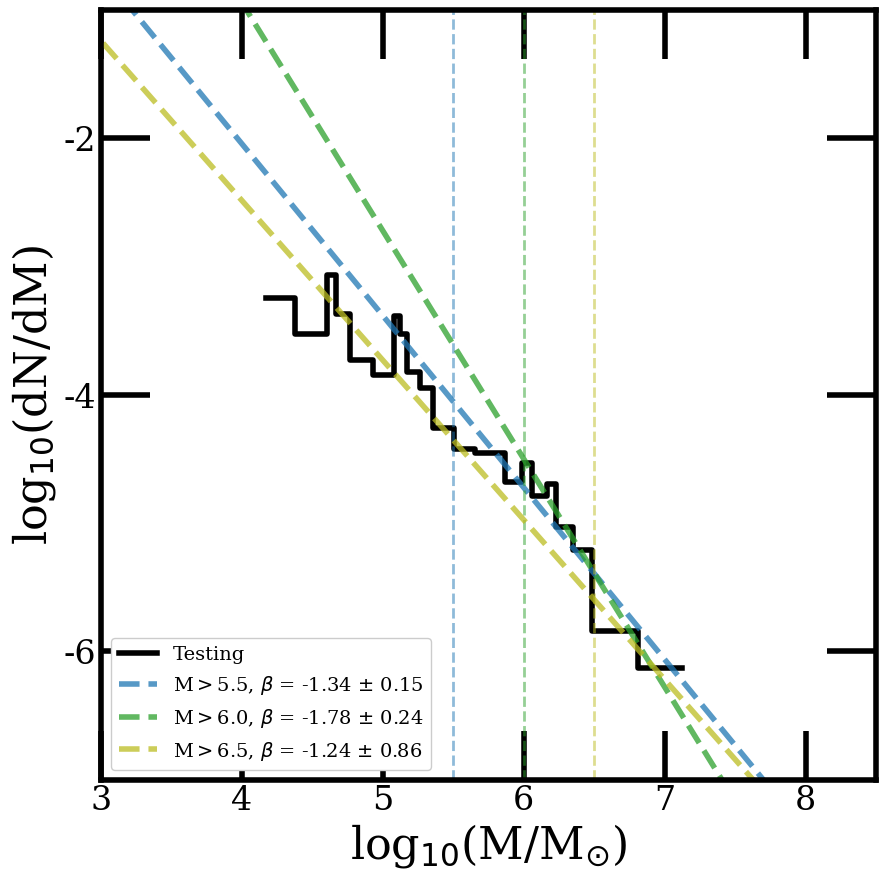

In [32]:
# How to run example:

# File in here
# I used .txt:
cl_arr_test = fin_txt('/Users/mandycaputo/Desktop/research/NGC1614/Check_cat_final_cent_smol.txt')
# But you could use dataframes:
# cl_arr_test = fin_df('/Users/mandycaputo/Desktop/research/NGC1614/Check_cat_final_cent_smol.txt')

# For each figure you want, Start with this:
figure(figsize=(10,10))

# To populate, use 'get_massfunct_hist'
# This will be populated with: (cl_arr,ageflag,label_in,color_in)
# cl_arr: What you get from the read in above
# ageflag: flags the age range to look at
# To pick age_flag: 1 = 0-10Myr, 2= 10-100Myr, 3 = 100-400Myr, 5=3-10Myr, 6=0-3Myr
# label_in: What you want line to be labeled as
# color_in: Color of line
bins_fit,n_fit_dM,n_fit_dM_err,array_plot=get_massfunct_hist(cl_arr_test,1,'Testing','k') # This gets all the histogram info. Needed before powerlaw plot
# You can plot multiple of these on the same plot. Just be careful on order
plt_powerlaw(10**5.5,'tab:blue',bins_fit,n_fit_dM,n_fit_dM_err,array_plot) # You can plot as many of these as you want after the above command
plt_powerlaw(10**6,'tab:green',bins_fit,n_fit_dM,n_fit_dM_err,array_plot) # like this
plt_powerlaw(10**6.5,'tab:olive',bins_fit,n_fit_dM,n_fit_dM_err,array_plot) # and this

end_plot() # when you are done with one, use this to make it look right

